<p style="font-size:30px;">Personalised cancer Diagnosis Case Study</p>

# INTRODUCTION

### The data is provided to us by MSKCC (Memorial Sloan Kettering Cancer Center).

### For a cancer tumour, there can be multiple genetic mutations possible, but the most difficult part is to separate the driver-mutations which contribute the most to the tumour growth. This task is currently done by a pathologist who manually reviews and categorises each genetic mutation using data based on based on evidence from text-based clinical literature. This process costs a huge amount of time and other resources. Our task is to build a Machine Learning model which helps us classify the genetic mutations, thus making it faster to find the right genetic mutation and treat the patients faster


### The model built must be interpretable, as it will help the pathologist to make better decisions. Since one misinterpretations can cost a patient his/her life, the error cost is very high

## OBJECTIVES AND CONSTRAINTS

##### No low-latency requirement.
##### Interpretability is important.
##### Errors can be very costly.
##### Probability of a data-point belonging to each class is needed.


## Type of Machine Learning Problem
##### There are nine different classes a genetic mutation can be classified into => Multi class classification problem

## Performance Metric
##### Multi class log-loss
##### Confusion matrix


## Machine Learing Objectives and Constraints
##### Objective: Predict the probability of each data-point belonging to each of the nine classes.

### Constraints:

##### Class probabilities are needed.
##### Penalize the errors in class probabilites => Metric is Log-loss.
##### No Latency constraints.


In [1]:
# splitting the dataset into three parts train ,test and cross validation ,64%,20%,16%



import pandas as pd
import matplotlib.pyplot as plt
import re
import time
import warnings
import numpy as np

## LOAD DATASET


In [2]:
df=pd.read_csv("training_variants/training_variants")
df

,ID,Gene,Variation,Class
0,0,FAM58A,Truncating Mutations,1
1,1,CBL,W802*,2
2,2,CBL,Q249E,2
3,3,CBL,N454D,3
4,4,CBL,L399V,4
...,...,...,...,...
3316,3316,RUNX1,D171N,4
3317,3317,RUNX1,A122*,1
3318,3318,RUNX1,Fusions,1
3319,3319,RUNX1,R80C,4


In [3]:
data_text =pd.read_csv("training_text/canctex",
                       sep=r"\|\|",engine="python",names=["ID","TEXT"],skiprows=1)

print('Number of data points : ', data_text.shape[0])
print('Number of features : ', data_text.shape[1])
print('Features : ', data_text.columns.values)
data_text.head()

Number of data points :  3321
Number of features :  2
Features :  ['ID' 'TEXT']


,ID,TEXT
0,0,Cyclin-dependent kinases (CDKs) regulate a var...
1,1,Abstract Background Non-small cell lung canc...
2,2,Abstract Background Non-small cell lung canc...
3,3,Recent evidence has demonstrated that acquired...
4,4,Oncogenic mutations in the monomeric Casitas B...


## EXPLORATORY DATA ANALYSIS

In [4]:
 import nltk
 nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nandh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
from nltk.corpus import stopwords
import re
# loading stop words from nltk library
stop_words = set(stopwords.words('english'))


def ml_preprocessing(total_text,index,column):
    if type(total_text) is not int:
        string=""
    total_text=re.sub('[^a-zA-Z0-9\n]',' ',total_text)
    total_text=re.sub(r'\s+',' ',total_text)
    total_text = total_text.lower()
    for word in total_text.split():
        if not word in stop_words:
            string += word+" "

    data_text.loc[index,column]=string




        
    


In [6]:
import time

#text processing stage.
start_time = time.perf_counter()
for index, row in data_text.iterrows():
    if type(row['TEXT']) is str:
        ml_preprocessing(row['TEXT'], index, 'TEXT')
    else:
        print("there is no text description for id:",index)
print('Time took for preprocessing the text : {0:.2f} seconds.'.format(time.perf_counter() - start_time))


there is no text description for id: 1109
there is no text description for id: 1277
there is no text description for id: 1407
there is no text description for id: 1639
there is no text description for id: 2755
Time took for preprocessing the text : 75.53 seconds.


In [7]:
result= pd.merge(df,data_text,on='ID',how='left')
result

,ID,Gene,Variation,Class,TEXT
0,0,FAM58A,Truncating Mutations,1,cyclin dependent kinases cdks regulate variety...
1,1,CBL,W802*,2,abstract background non small cell lung cancer...
2,2,CBL,Q249E,2,abstract background non small cell lung cancer...
3,3,CBL,N454D,3,recent evidence demonstrated acquired uniparen...
4,4,CBL,L399V,4,oncogenic mutations monomeric casitas b lineag...
...,...,...,...,...,...
3316,3316,RUNX1,D171N,4,introduction myelodysplastic syndromes mds het...
3317,3317,RUNX1,A122*,1,introduction myelodysplastic syndromes mds het...
3318,3318,RUNX1,Fusions,1,runt related transcription factor 1 gene runx1...
3319,3319,RUNX1,R80C,4,runx1 aml1 gene frequent target chromosomal tr...


In [8]:

null_records=result[result.isnull().any(axis=1)]
null_records_ids=null_records['ID']
null_records

,ID,Gene,Variation,Class,TEXT
1109,1109,FANCA,S1088F,1,NaN
1277,1277,ARID5B,Truncating Mutations,1,NaN
1407,1407,FGFR3,K508M,6,NaN
1639,1639,FLT1,Amplification,6,NaN
2755,2755,BRAF,G596C,7,NaN


In [9]:
result.loc[result['TEXT'].isnull(),'TEXT']= result['Gene']+' '+result['Variation']

In [10]:
result[result['ID'].isin(null_records_ids)]

,ID,Gene,Variation,Class,TEXT
1109,1109,FANCA,S1088F,1,FANCA S1088F
1277,1277,ARID5B,Truncating Mutations,1,ARID5B Truncating Mutations
1407,1407,FGFR3,K508M,6,FGFR3 K508M
1639,1639,FLT1,Amplification,6,FLT1 Amplification
2755,2755,BRAF,G596C,7,BRAF G596C


In [11]:
from sklearn.model_selection import train_test_split
y_true = result['Class'].values
result.Gene      = result.Gene.str.replace(r'\s+', '_', regex=True)
result.Variation = result.Variation.str.replace(r'\s+', '_', regex=True)

X_train, test_df, y_train, y_test = train_test_split(result, y_true, stratify=y_true, test_size=0.2)
train_df, cv_df, y_train, y_cv = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2)

In [12]:
print('Number of data points in train data:', train_df.shape[0])
print('Number of data points in test data:', test_df.shape[0])
print('Number of data points in cross validation data:', cv_df.shape[0])


Number of data points in train data: 2124
Number of data points in test data: 665
Number of data points in cross validation data: 532


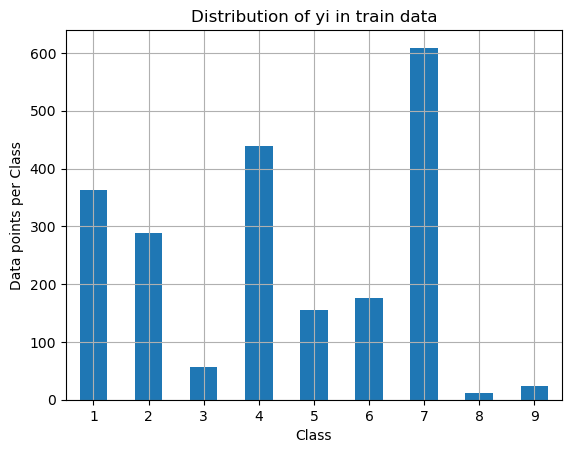

Number of data points in class 7: 191, (28.672%)
Number of data points in class 4: 137, (20.669%)
Number of data points in class 1: 114, (17.09%)
Number of data points in class 2: 91, (13.606%)
Number of data points in class 6: 55, (8.286%)
Number of data points in class 5: 48, (7.298%)
Number of data points in class 3: 18, (2.684%)
Number of data points in class 9: 7, (1.13%)
Number of data points in class 8: 4, (0.565%)
--------------------------------------------------------------------------------


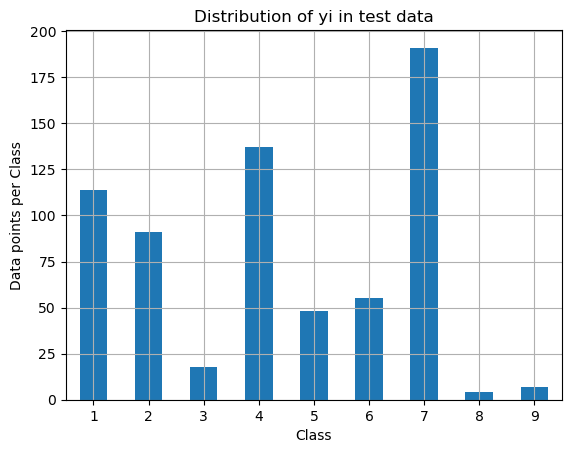

Number of data points in class 7: 191, (28.722%)
Number of data points in class 4: 137, (20.602%)
Number of data points in class 1: 114, (17.143%)
Number of data points in class 2: 91, (13.684%)
Number of data points in class 6: 55, (8.271%)
Number of data points in class 5: 48, (7.218%)
Number of data points in class 3: 18, (2.707%)
Number of data points in class 9: 7, (1.053%)
Number of data points in class 8: 4, (0.602%)
--------------------------------------------------------------------------------


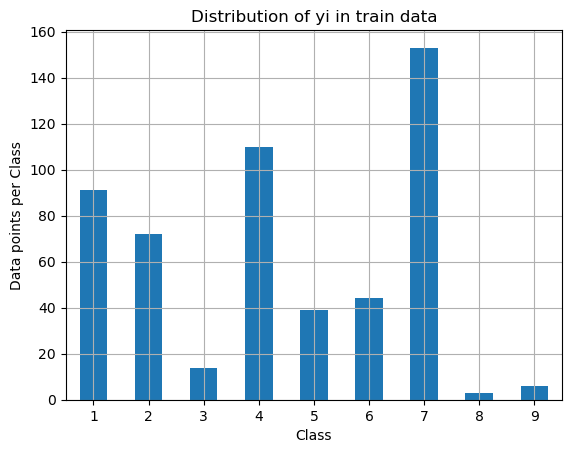

Number of data points in class 7: 153, (28.759%)
Number of data points in class 4: 110, (20.677%)
Number of data points in class 1: 91, (17.105%)
Number of data points in class 2: 72, (13.534%)
Number of data points in class 6: 44, (8.271%)
Number of data points in class 5: 39, (7.331%)
Number of data points in class 3: 14, (2.632%)
Number of data points in class 9: 6, (1.128%)
Number of data points in class 8: 3, (0.564%)


In [13]:
# it returns a dict, keys as class labels and values as the number of data points in that class
train_class_distribution = train_df['Class'].value_counts().sort_index()
test_class_distribution = test_df['Class'].value_counts().sort_index()
cv_class_distribution = cv_df['Class'].value_counts().sort_index()

# my_colors = 'rgbkymc'
train_class_distribution.plot(kind='bar', xlabel='Class', ylabel='Data points per Class', 
                              title='Distribution of yi in train data', grid=True, rot=0)
plt.show()


sorted_yi = np.argsort(train_class_distribution.values)[::-1]
for i in sorted_yi:
    print("Number of data points in class {}: {}, ({}%)"
          .format(i+1, test_class_distribution.values[i],
                  np.round((train_class_distribution.values[i]/train_df.shape[0]*100), 3)))
    
print('-'*80)
# my_colors = 'rgbkymc'
test_class_distribution.plot(kind='bar', xlabel='Class', ylabel='Data points per Class', 
                              title='Distribution of yi in test data', grid=True, rot=0)
plt.show()


sorted_yi = np.argsort(train_class_distribution.values)[::-1]
for i in sorted_yi:
    print("Number of data points in class {}: {}, ({}%)"
          .format(i+1, test_class_distribution.values[i],
                  np.round((test_class_distribution.values[i]/test_df.shape[0]*100), 3)))


print('-'*80)
# my_colors = 'rgbkymc'
cv_class_distribution.plot(kind='bar', xlabel='Class', ylabel='Data points per Class', 
                              title='Distribution of yi in train data', grid=True, rot=0)
plt.show()

sorted_yi = np.argsort(train_class_distribution.values)[::-1]
for i in sorted_yi:
    print("Number of data points in class {}: {}, ({}%)"
          .format(i+1, cv_class_distribution.values[i],
                  np.round((cv_class_distribution.values[i]/cv_df.shape[0]*100), 3)))

In [14]:
plt.style.use('tableau-colorblind10')
import seaborn as sns
sns.set_palette('colorblind')

In [15]:
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(test_y,predicted_y):
    cfn_matrix=confusion_matrix(test_y,predicted_y)
    recall=cfn_matrix/cfn_matrix.sum(axis=1).reshape(cfn_matrix.shape[0],1)
    precision=cfn_matrix/cfn_matrix.sum(axis=0)
    labels=[1,2,3,4,5,6,7,8,9]
    
    print('='*20,'confusion_matrix','='*20)
    plt.figure(figsize=(20,7))
    sns.heatmap(cfn_matrix,annot=True,cmap='YlGnBu',fmt='.3f',xticklabels=labels,yticklabels=labels)
    plt.xlabel('predicted class')
    plt.ylabel('original class')
    plt.show()
    
    print('='*20,'recall','='*20)
    plt.figure(figsize=(20,7))
    sns.heatmap(recall,annot=True,cmap='YlGnBu',fmt='.3f',xticklabels=labels,yticklabels=labels)
    plt.xlabel('predicted class')
    plt.ylabel('original class')
    plt.show()
    
    print('='*20,'precision','='*20)
    plt.figure(figsize=(20,7))
    sns.heatmap(precision,annot=True,cmap='YlGnBu',fmt='.3f',xticklabels=labels,yticklabels=labels)
    plt.xlabel('predicted class')
    plt.ylabel('original class')
    plt.show()









log loss on cross validation data using random model is 2.503708184411181
log loss on test data using random model is 2.5107970445042733
==================== confusion_matrix ====================


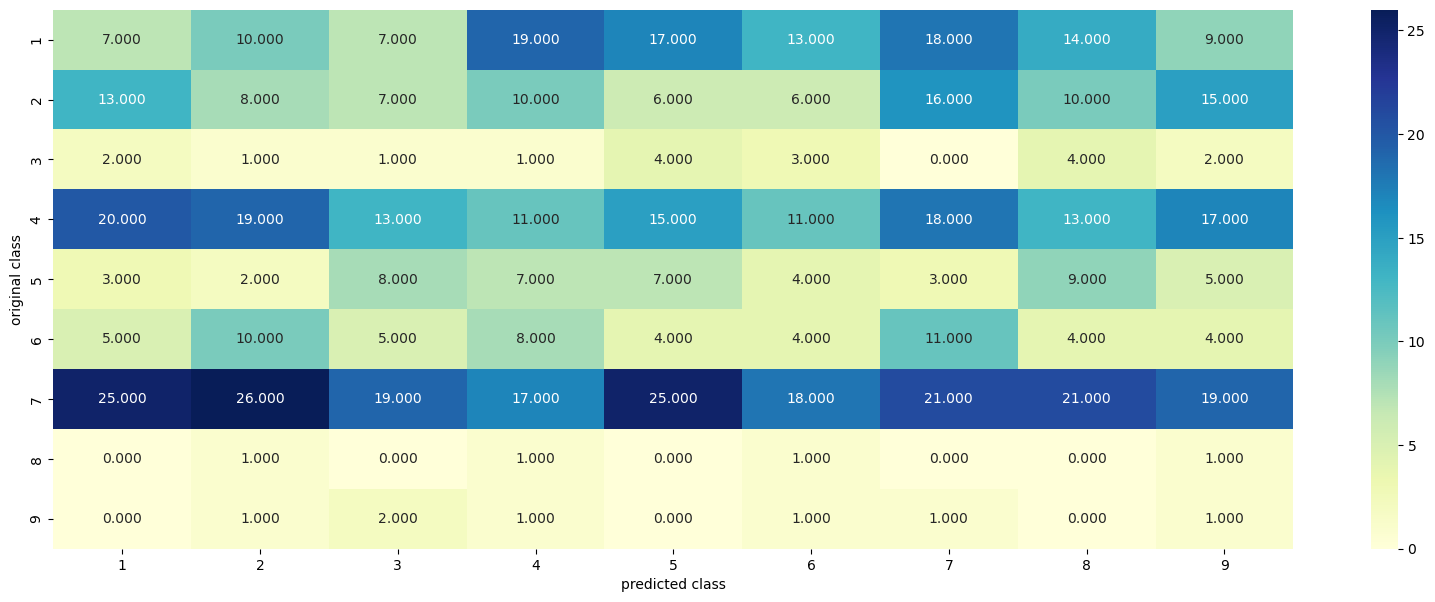

==================== recall ====================


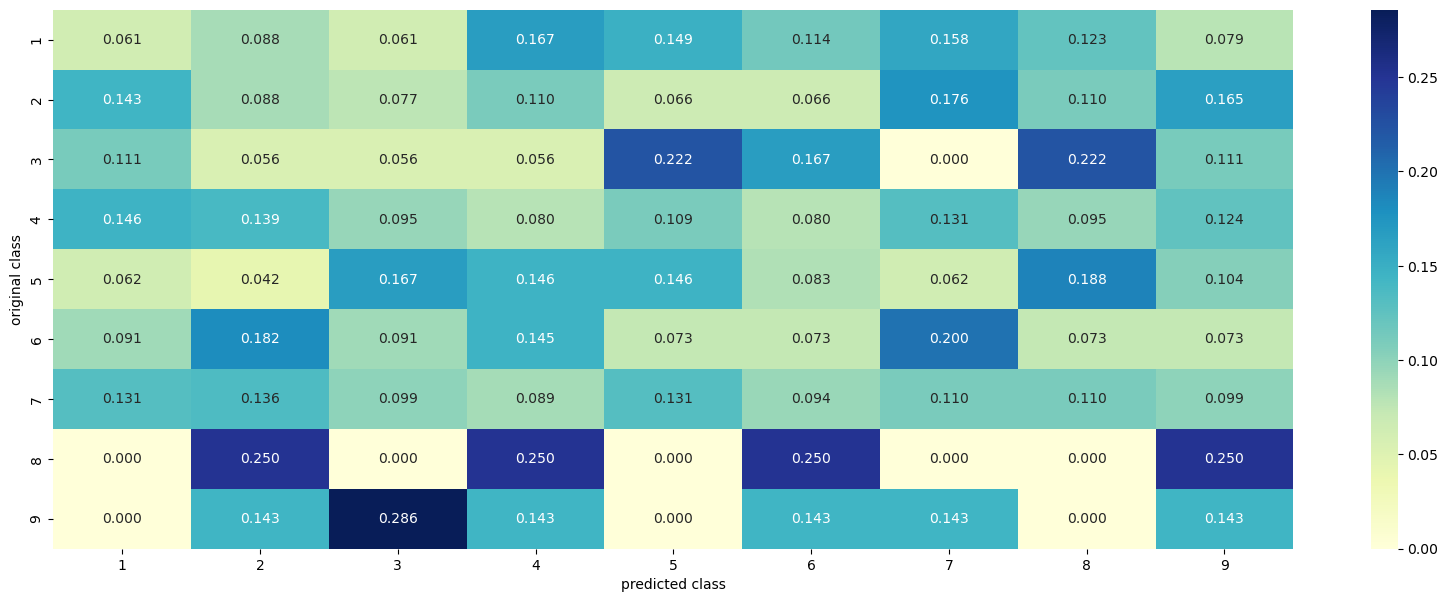

==================== precision ====================


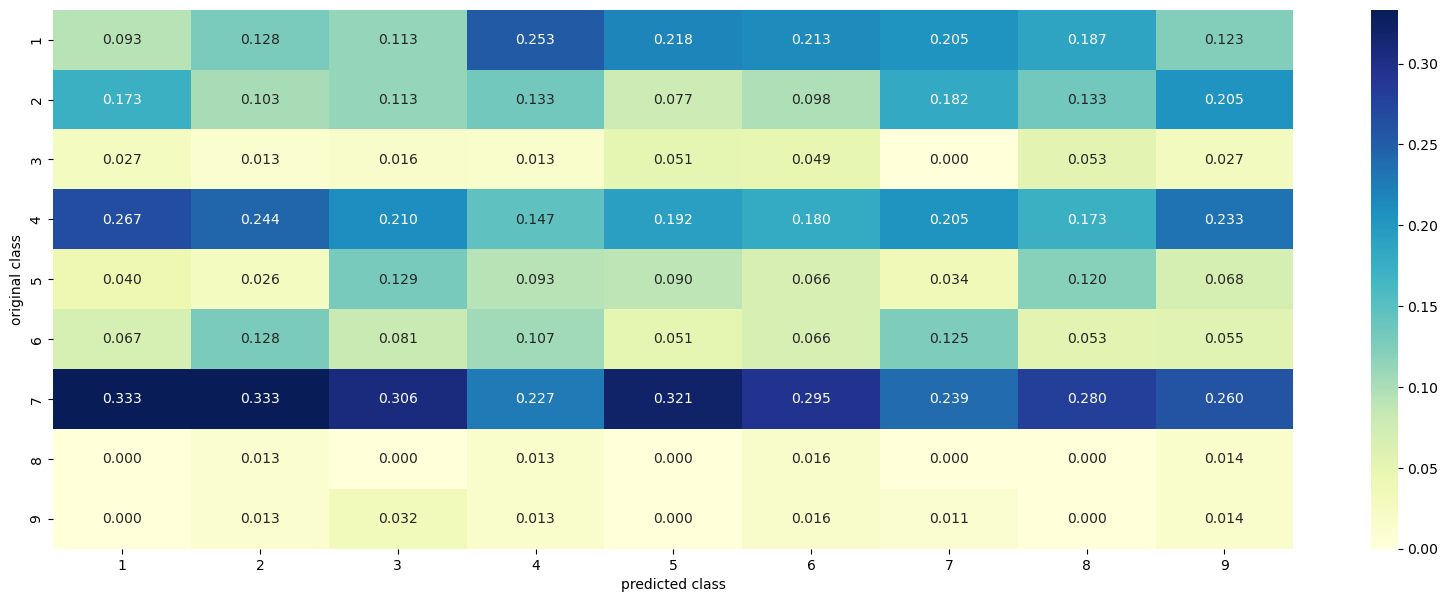

In [16]:
from sklearn.metrics import log_loss

np.random.seed(42)
cv_df_len=cv_df.shape[0]
cv_predicted_y=np.zeros((cv_df_len,9))
for i in range(cv_df_len):
    rand_probs=np.random.rand(9)
    cv_predicted_y[i]=rand_probs/sum(rand_probs)
print('log loss on cross validation data using random model is',log_loss(y_cv,cv_predicted_y))



test_data_len=test_df.shape[0]
test_predicted_y=np.zeros((test_data_len,9))
for i in range(test_data_len):
    random_probs=np.random.rand(9)
    test_predicted_y[i]= random_probs/sum(random_probs)

print('log loss on test data using random model is',log_loss(y_test,test_predicted_y))
predicted_y = np.argmax(test_predicted_y, axis=1) + 1
plot_confusion_matrix(y_test, predicted_y)


In [17]:


def get_gv_fea_dict(alpha, feature, df):
    
    class_cnt = train_df['Class'].value_counts()
    unique_values = train_df[feature].unique()
    
    gv_dict = dict()

    
    for value in unique_values:
        
        vec = []
        for class_ in range(1,10):
          
            value_with_class = train_df.loc[(train_df['Class']==class_) & (train_df[feature]==value)]
            
           
            vec.append((value_with_class.shape[0] + alpha*10)/ (class_cnt[class_] + 90*alpha))

        
        gv_dict[value] = vec
    return gv_dict


def get_gv_feature(alpha, feature, df):
    
    gv_dict = get_gv_fea_dict(alpha, feature, df)
   
    gv_fea = []
   
    for index, row in df.iterrows():
        if row[feature] in gv_dict:
            gv_fea.append(gv_dict[row[feature]])
        else:
            gv_fea.append([1/9,1/9,1/9,1/9,1/9,1/9,1/9,1/9,1/9])
    return gv_fea



















In [18]:
unique_genes=train_df['Gene'].value_counts()
print('the number of Unique genes are:',unique_genes.shape[0])
print('the top 10 most occuring genes are:')
unique_genes.head(10)

the number of Unique genes are: 233
the top 10 most occuring genes are:


Gene
BRCA1     173
TP53      102
EGFR       97
PTEN       80
BRCA2      69
KIT        64
BRAF       64
ALK        45
ERBB2      39
PIK3CA     37
Name: count, dtype: int64

In [19]:
print("Ans: There are", unique_genes.shape[0] ,"different categories of genes in the train data, and they are distibuted as follows",)

Ans: There are 233 different categories of genes in the train data, and they are distibuted as follows


<function matplotlib.pyplot.show(close=None, block=None)>

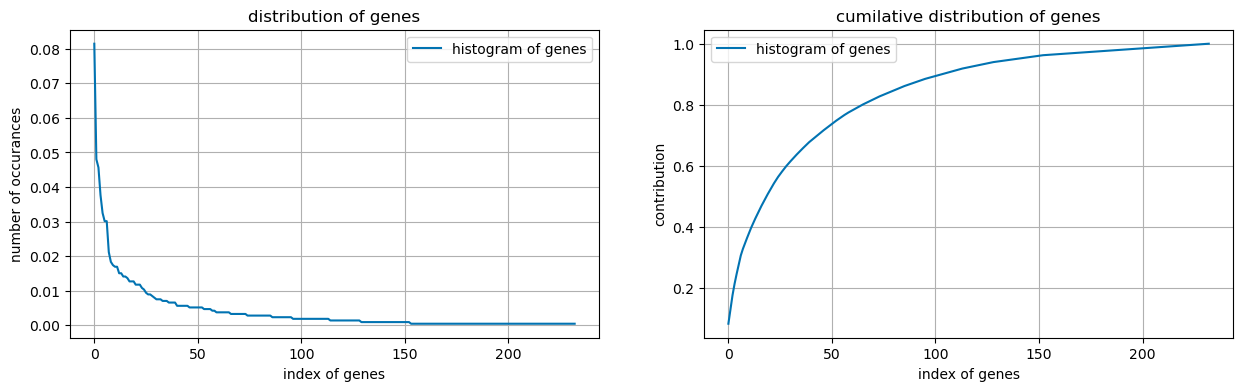

In [20]:
plt.figure(figsize=(15,4))


plt.subplot(1,2,1)
s=sum(unique_genes.values)
h=unique_genes.values/s
plt.plot(h,label="histogram of genes")
plt.xlabel("index of genes")
plt.ylabel("number of occurances")
plt.title("distribution of genes")
plt.legend()
plt.grid()


plt.subplot(1,2,2)
c=np.cumsum(h)
plt.plot(c,label="histogram of genes")
plt.xlabel("index of genes")
plt.ylabel("contribution")
plt.title("cumilative distribution of genes")
plt.legend()
plt.grid()
plt.show







## FEATURE ENGINEERING

In [21]:
# response-coding of the Gene feature
# ====================================
# alpha is used for laplace smoothing
alpha = 1
# train gene feature
train_gene_feature_responseCoding = np.array(get_gv_feature(alpha, "Gene", train_df))
# test gene feature
test_gene_feature_responseCoding = np.array(get_gv_feature(alpha, "Gene", test_df))
# cross validation gene feature
cv_gene_feature_responseCoding = np.array(get_gv_feature(alpha, "Gene", cv_df))


In [22]:
print("train_gene_feature_responseCoding is converted feature using respone coding method. The shape of gene feature:", train_gene_feature_responseCoding.shape)


train_gene_feature_responseCoding is converted feature using respone coding method. The shape of gene feature: (2124, 9)


In [23]:
# one-hot encoding of Gene feature.
# =================================
from sklearn.feature_extraction.text import CountVectorizer

gene_vectorizer = CountVectorizer()
train_gene_feature_onehotCoding = gene_vectorizer.fit_transform(train_df['Gene'])
test_gene_feature_onehotCoding = gene_vectorizer.transform(test_df['Gene'])
cv_gene_feature_onehotCoding = gene_vectorizer.transform(cv_df['Gene'])

In [24]:
train_df['Gene'].head()

2969       KIT
615      FBXW7
2295     PRDM1
949     PDGFRB
170       EGFR
Name: Gene, dtype: object

In [25]:
genes = gene_vectorizer.get_feature_names_out()
print(genes, end=' ')

['abl1' 'acvr1' 'ago2' 'akt1' 'akt2' 'akt3' 'alk' 'apc' 'ar' 'araf'
 'arid1b' 'arid2' 'arid5b' 'asxl1' 'atm' 'atr' 'atrx' 'aurka' 'aurkb'
 'axin1' 'axl' 'b2m' 'bap1' 'bard1' 'bcl10' 'bcl2l11' 'bcor' 'braf'
 'brca1' 'brca2' 'brip1' 'btk' 'card11' 'carm1' 'casp8' 'cbl' 'ccnd1'
 'ccnd3' 'ccne1' 'cdh1' 'cdk12' 'cdk4' 'cdkn1a' 'cdkn1b' 'cdkn2a' 'cdkn2b'
 'cdkn2c' 'cebpa' 'chek2' 'cic' 'crebbp' 'ctcf' 'ctla4' 'ctnnb1' 'ddr2'
 'dicer1' 'dnmt3a' 'dnmt3b' 'dusp4' 'egfr' 'elf3' 'ep300' 'epas1' 'erbb2'
 'erbb3' 'erbb4' 'ercc2' 'ercc3' 'ercc4' 'erg' 'errfi1' 'esr1' 'etv1'
 'etv6' 'ewsr1' 'ezh2' 'fam58a' 'fanca' 'fat1' 'fbxw7' 'fgf19' 'fgf3'
 'fgf4' 'fgfr1' 'fgfr2' 'fgfr3' 'fgfr4' 'flt1' 'flt3' 'foxa1' 'foxl2'
 'foxp1' 'fubp1' 'gata3' 'gli1' 'gnaq' 'gnas' 'h3f3a' 'hist1h1c' 'hla'
 'hnf1a' 'hras' 'idh1' 'idh2' 'igf1r' 'ikzf1' 'il7r' 'inpp4b' 'jak1'
 'jak2' 'jun' 'kdm5c' 'kdm6a' 'kdr' 'keap1' 'kit' 'klf4' 'kmt2b' 'kmt2c'
 'kmt2d' 'knstrn' 'kras' 'lats1' 'map2k1' 'map2k2' 'map2k4' 'map3k1'
 'mapk1' 'm

In [26]:
print("train_gene_feature_onehotCoding is converted feature using one-hot encoding method. The shape of gene feature:", train_gene_feature_onehotCoding.shape)

train_gene_feature_onehotCoding is converted feature using one-hot encoding method. The shape of gene feature: (2124, 233)


for values of alpha 1e-05 The log_loss is: 1.202396681019486
for values of alpha 0.0001 The log_loss is: 1.181201594164297
for values of alpha 0.001 The log_loss is: 1.225451261769602
for values of alpha 0.01 The log_loss is: 1.3248949980772917
for values of alpha 0.1 The log_loss is: 1.4280540822952474
for values of alpha 1 The log_loss is: 1.4615367455225343


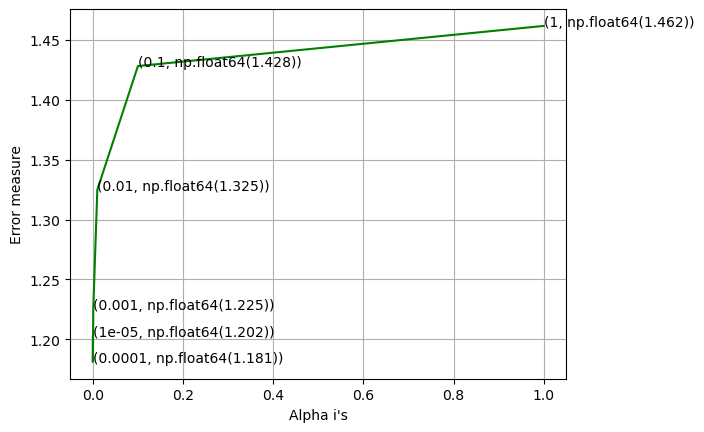

for the values of best alpha 0.0001 the log_loss is 0.9937181012095061
for the values of best alpha 0.0001 the log_loss is 1.181201594164297
for the values of best alpha 0.0001 the log_loss is 1.1800965056636827


In [27]:
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

alpha = [10**x for x in range (-5,1)]

cv_log_error_array=[]

for i in alpha:
    clf=SGDClassifier(alpha=i, penalty='l2' ,loss='log_loss',n_jobs=-1,random_state=42)
    
    clf.fit(train_gene_feature_onehotCoding,y_train)
    sig_clf= CalibratedClassifierCV(clf,method='sigmoid')
    sig_clf.fit(train_gene_feature_onehotCoding,y_train)
    predict_y=sig_clf.predict_proba(cv_gene_feature_onehotCoding)
    cv_log_error_array.append(log_loss(y_cv,predict_y,labels=clf.classes_))
    print('for values of alpha',i,'The log_loss is:',log_loss(y_cv,predict_y,labels=clf.classes_))


fig, ax = plt.subplots()
ax.plot(alpha, cv_log_error_array,c='g')
for i,txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],np.round(txt,3)),(alpha[i],cv_log_error_array[i]))
plt.grid()
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()


best_alpha=np.argmin(cv_log_error_array)
clf=SGDClassifier(alpha=alpha[best_alpha],penalty='l2',loss='log_loss', n_jobs=-1, random_state=42)
clf.fit(train_gene_feature_onehotCoding,y_train)
sig_clf=CalibratedClassifierCV(clf,method='sigmoid')
sig_clf.fit(train_gene_feature_onehotCoding,y_train)

predict_y = sig_clf.predict_proba(train_gene_feature_onehotCoding)
print('for the values of best alpha',alpha[best_alpha],'the log_loss is',log_loss(y_train,predict_y,labels=clf.classes_))
predict_y = sig_clf.predict_proba(cv_gene_feature_onehotCoding)
print('for the values of best alpha',alpha[best_alpha],'the log_loss is',log_loss(y_cv,predict_y,labels=clf.classes_))
predict_y = sig_clf.predict_proba(test_gene_feature_onehotCoding)
print('for the values of best alpha',alpha[best_alpha],'the log_loss is',log_loss(y_test,predict_y,labels=clf.classes_))


In [28]:
print("Q6. How many data points in Test and CV datasets are covered by the ", unique_genes.shape[0], " genes in train dataset?")
test_coverage=test_df[test_df['Gene'].isin(train_df['Gene'])].shape[0]
cv_coverage=cv_df[cv_df['Gene'].isin(train_df['Gene'])].shape[0]
print('the percentage of points in test data whose genes are present train data',(test_coverage/test_df.shape[0])*100 )
print('the percentage of points in cross validation data whose genes are present in train data',(cv_coverage/cv_df.shape[0])*100)

Q6. How many data points in Test and CV datasets are covered by the  233  genes in train dataset?
the percentage of points in test data whose genes are present train data 96.69172932330827
the percentage of points in cross validation data whose genes are present in train data 96.80451127819549


In [29]:
from IPython.display import display, HTML

display(HTML("<h1>Univariate analysis on variation feature</h1>"))


In [30]:
unique_variations=train_df['Variation'].value_counts()
print("the number of Unique variations are",unique_variations.shape[0])
print("the top 10 most frequently occuring variations")
unique_variations.head(10)

the number of Unique variations are 1935
the top 10 most frequently occuring variations


Variation
Truncating_Mutations    61
Amplification           48
Deletion                42
Fusions                 24
Overexpression           4
S222D                    2
M1R                      2
Y64A                     2
G35R                     2
V321M                    2
Name: count, dtype: int64

In [31]:

print("there are ",unique_variations.shape[0],'different categories variations in the train the train data and the distribution is as follows:')

there are  1935 different categories variations in the train the train data and the distribution is as follows:


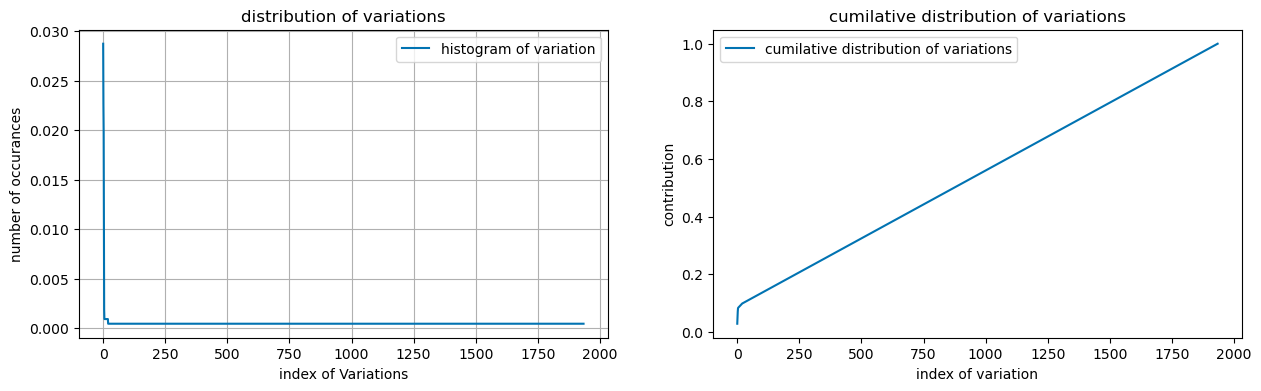

In [32]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
s=sum(unique_variations.values)
h=unique_variations.values/s
plt.plot(h,label='histogram of variation')
plt.legend()
plt.grid()
plt.title("distribution of variations")
plt.xlabel("index of Variations")
plt.ylabel("number of occurances")

plt.subplot(1,2,2)
c= np.cumsum(h)
plt.plot(c,label="cumilative distribution of variations")
plt.title("cumilative distribution of variations")
plt.legend()
plt.grid
plt.ylabel("contribution")
plt.xlabel("index of variation")


plt.show()

featurization of  Variations

In [33]:
#response coding
alpha=1
train_variation_feature_responsecoding=np.array(get_gv_feature(alpha,'Variation',train_df))
test_variation_feature_responsecoding=np.array(get_gv_feature(alpha,'Variation',test_df))
cv_variation_feature_responsecoding=np.array(get_gv_feature(alpha,'Variation',cv_df))
print("train_variation_feature_responsecoding is the coverted feature Variation now the shape of the frature Variation is ",train_variation_feature_responsecoding.shape)

train_variation_feature_responsecoding is the coverted feature Variation now the shape of the frature Variation is  (2124, 9)


In [34]:
#one hot enocoding of variation feature
from sklearn.feature_extraction.text import CountVectorizer
variation_vectorizer= CountVectorizer()
train_variation_feature_onehotcoding=variation_vectorizer.fit_transform(train_df['Variation'])
test_variation_feature_onehotcoding=variation_vectorizer.transform(test_df['Variation'])
cv_variation_feature_onehotcoding=variation_vectorizer.transform(cv_df['Variation'])
print('train_variation_feature_onehotcoding is converted variation feature whose shape is',train_variation_feature_onehotcoding.shape)




train_variation_feature_onehotcoding is converted variation feature whose shape is (2124, 1961)


# how good the variation feature in predicting Yi


 for values of alpha= 1e-05  the cross validation log error  1.6959872640213736
 for values of alpha= 0.0001  the cross validation log error  1.682095993861866
 for values of alpha= 0.001  the cross validation log error  1.6876238856744903
 for values of alpha= 0.01  the cross validation log error  1.6999100295828111
 for values of alpha= 0.1  the cross validation log error  1.7062884269913283
 for values of alpha= 1  the cross validation log error  1.7089702163053415


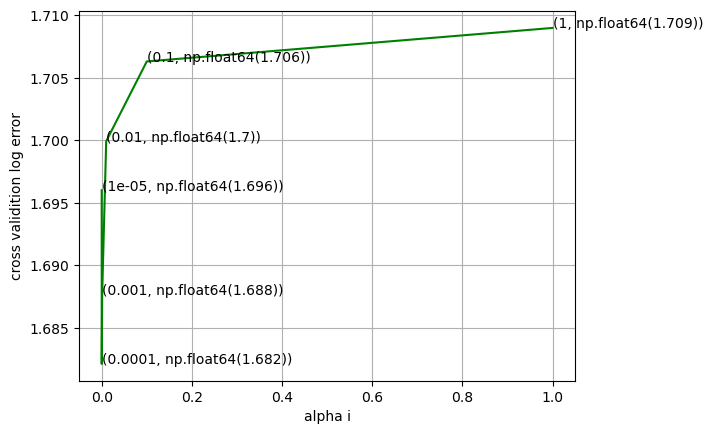

for the value of best alpha 0.0001 the train error is 0.6682304930704785
for the value of best alpha 0.0001 the cross validation error is 1.682095993861866
for the value of best alpha 0.0001 the test error is 1.7156368556223396


In [35]:
alpha=[10**x for x in range(-5,1)]
cv_log_error_array=[]

for i in alpha:
    clf=SGDClassifier(alpha=i,penalty='l2',loss='log_loss', n_jobs=-1, random_state=42)
    sig_clf=CalibratedClassifierCV(clf,method='sigmoid')
    sig_clf.fit(train_variation_feature_onehotcoding,y_train)
    predict_y=sig_clf.predict_proba(cv_variation_feature_onehotcoding)
    cv_log_error_array.append(log_loss(y_cv,predict_y, labels=sig_clf.classes_))
    print(" for values of alpha=",i," the cross validation log error ",log_loss(y_cv,predict_y, labels=sig_clf.classes_))


fig ,ax =plt.subplots()
ax.plot(alpha,cv_log_error_array,c='g')
for i,txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],np.round(txt,3)),(alpha[i],cv_log_error_array[i]))
plt.xlabel("alpha i")
plt.ylabel("cross validition log error")
plt.grid()
plt.show()


best_alpha=np.argmin(cv_log_error_array)
clf=SGDClassifier(alpha=alpha[best_alpha],penalty='l2',loss='log_loss', n_jobs=-1, random_state=42)
sig_clf=CalibratedClassifierCV(clf,method='sigmoid')
sig_clf.fit(train_variation_feature_onehotcoding,y_train)


predict_y=sig_clf.predict_proba(train_variation_feature_onehotcoding)
print("for the value of best alpha",alpha[best_alpha],"the train error is",log_loss(y_train,predict_y,labels=sig_clf.classes_))
predict_y=sig_clf.predict_proba(cv_variation_feature_onehotcoding)
print("for the value of best alpha",alpha[best_alpha],"the cross validation error is",log_loss(y_cv,predict_y,labels=sig_clf.classes_))
predict_y=sig_clf.predict_proba(test_variation_feature_onehotcoding)
print("for the value of best alpha",alpha[best_alpha],"the test error is",log_loss(y_test,predict_y,labels=sig_clf.classes_))










In [36]:
# checking the stablity of feature
test_coverage=test_df[test_df['Variation'].isin(train_df['Variation'])].shape[0]
print("the percentage of the points in test data whose varation is train data is",(test_coverage/test_df.shape[0])*100)
cv_coverage=cv_df[cv_df['Variation'].isin(train_df['Variation'])].shape[0]
print("the percentage of the points in cross validation data whose varation is train data is",(cv_coverage/cv_df.shape[0])*100)

the percentage of the points in test data whose varation is train data is 9.774436090225564
the percentage of the points in cross validation data whose varation is train data is 11.654135338345863


# univariate analysis on text feature

In [37]:
from collections import defaultdict
def extract_dictionary_paddle(cls_text):
    dictionary=defaultdict(int)
    for index,row in cls_text.iterrows():
        for word in set(row['TEXT'].split()):
            dictionary[word]+=1
            
    return dictionary
dict_list=[]

for i in range(1,10):
    cls_text=train_df[train_df['Class']==1]
    dict_list.append(extract_dictionary_paddle(cls_text))

class_cnt=train_df['Class'].value_counts().to_dict()
    

In [38]:
import math
from tqdm import tqdm
def get_text_responsecoding(df):
    text_feature_responsecoding=np.zeros((df.shape[0],9))
    for index,row in tqdm(df.reset_index(drop=True).iterrows(),total=df.shape[0]):
        for class_ in range(9):
            sum_prob=0
            for word in row['TEXT'].split():
                sum_prob +=math.log((dict_list[class_].get(word,0)+10)/(class_cnt[class_+1] + 90))
            text_feature_responsecoding[index,class_]=math.exp(sum_prob / len(row['TEXT'].split()))
    return text_feature_responsecoding

In [39]:

#one_hot_encoding

from sklearn.feature_extraction.text import CountVectorizer
text_vectorizer=CountVectorizer(min_df=3)
train_text_feature_onehotCoding = text_vectorizer.fit_transform(train_df['TEXT'])
train_text_features= text_vectorizer.get_feature_names_out()
train_text_fea_count=np.asarray(train_text_feature_onehotCoding.sum(axis=0)).ravel()
text_fea_dict = dict(zip(train_text_features,train_text_fea_count))

print("the total of unique words in the train data is",len(text_fea_dict ))


the total of unique words in the train data is 54433


In [40]:
import math
from tqdm import tqdm
def get_text_responsecoding(df):
    text_feature_responseCoding = np.zeros((df.shape[0], 9))
    for index, row in tqdm(df.reset_index(drop=True).iterrows(), total=df.shape[0]):
        for class_ in range(9):
            sum_prob = 0
            for word in row['TEXT'].split():
                sum_prob += math.log((dict_list[class_].get(word, 0) + 10) / (class_cnt[class_+1] + 90))
            text_feature_responseCoding[index, class_] = math.exp(sum_prob / len(row['TEXT'].split()))
    return text_feature_responseCoding

In [41]:
#response codings
train_text_feature_responseCoding  = get_text_responsecoding(train_df)
test_text_feature_responseCoding  = get_text_responsecoding(test_df)
cv_text_feature_responseCoding  = get_text_responsecoding(cv_df)
print("Done!")


100%|████████████████████████████████████████████████████████████████████████████████| 532/532 [00:20<00:00, 25.73it/s]

Done!


In [42]:
rows = train_text_feature_responseCoding.shape[0]
train_text_feature_responseCoding = train_text_feature_responseCoding / train_text_feature_responseCoding.sum(axis=1).reshape(rows, 1)

rows = test_text_feature_responseCoding.shape[0]
test_text_feature_responseCoding = test_text_feature_responseCoding / test_text_feature_responseCoding.sum(axis=1).reshape(rows, 1)

rows = cv_text_feature_responseCoding.shape[0]
cv_text_feature_responseCoding = cv_text_feature_responseCoding /cv_text_feature_responseCoding.sum(axis=1).reshape(rows, 1)

In [43]:
from sklearn.preprocessing import normalize
train_text_feature_onehotCoding =normalize(train_text_feature_onehotCoding,axis=0)
test_text_feature_onehotCoding = text_vectorizer.transform(test_df['TEXT'])
test_text_feature_onehotCoding = normalize(text_vectorizer.transform(test_df['TEXT']),axis=0)
cv_text_feature_onehotCoding = text_vectorizer.transform(cv_df['TEXT'])
cv_text_feature_onehotCoding = normalize(text_vectorizer.transform(cv_df['TEXT']),axis=0)

In [44]:
sorted_text_fea_dict = dict(sorted(text_fea_dict.items(), key=lambda x: x[1] , reverse=True))
sorted_text_occur =np.array(list(sorted_text_fea_dict.values()))

In [45]:
sorted_text_fea_dict = dict(sorted(text_fea_dict.items(), key=lambda x: x[1] , reverse=True))
sorted_text_occur = np.array(list(sorted_text_fea_dict.values()))

In [46]:
sorted_text_occur

array([155017, 121141,  83066, ...,      3,      3,      3],
      shape=(54433,))

In [47]:
from collections import Counter

# Number of words for a given frequency.
print(Counter(sorted_text_occur))

Counter({np.int64(3): 5550, np.int64(4): 4139, np.int64(6): 3423, np.int64(5): 2645, np.int64(8): 2206, np.int64(7): 1835, np.int64(10): 1664, np.int64(9): 1425, np.int64(12): 1333, np.int64(14): 1183, np.int64(11): 1074, np.int64(16): 865, np.int64(13): 852, np.int64(15): 795, np.int64(18): 727, np.int64(20): 716, np.int64(17): 670, np.int64(24): 503, np.int64(21): 480, np.int64(19): 474, np.int64(22): 459, np.int64(36): 428, np.int64(28): 421, np.int64(25): 408, np.int64(23): 358, np.int64(30): 353, np.int64(27): 342, np.int64(32): 324, np.int64(26): 314, np.int64(34): 288, np.int64(50): 287, np.int64(29): 287, np.int64(33): 272, np.int64(42): 256, np.int64(40): 256, np.int64(31): 252, np.int64(35): 248, np.int64(37): 218, np.int64(38): 210, np.int64(43): 190, np.int64(45): 188, np.int64(39): 188, np.int64(41): 173, np.int64(48): 169, np.int64(46): 159, np.int64(51): 158, np.int64(44): 154, np.int64(62): 151, np.int64(56): 148, np.int64(49): 147, np.int64(52): 145, np.int64(54): 135,

for values of alpha equal to 1e-05  the cross validation log_loss error  1.30319707669919
for values of alpha equal to 0.0001  the cross validation log_loss error  1.2058648006894372
for values of alpha equal to 0.001  the cross validation log_loss error  1.2007100459586004
for values of alpha equal to 0.01  the cross validation log_loss error  1.3177256418778693
for values of alpha equal to 0.1  the cross validation log_loss error  1.5085031114544847
for values of alpha equal to 1  the cross validation log_loss error  1.676547477336265


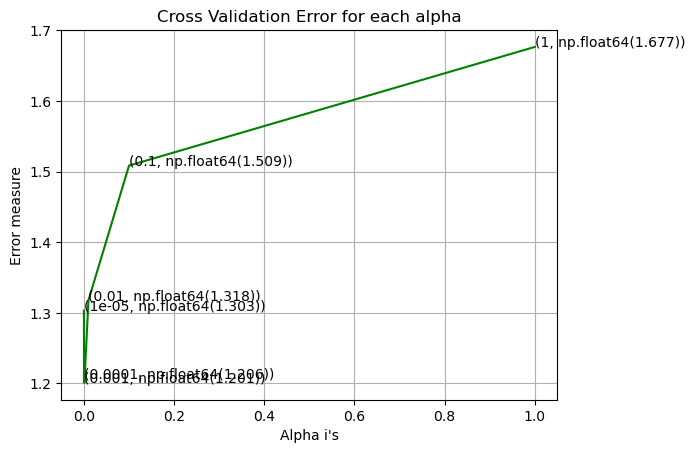

for the best alpha value 0.001 the traing log loss error is 0.6315358983347376
for the best alpha value 0.001 the traing log loss error is 1.2007100459586004
for the best alpha value 0.001 the traing log loss error is 1.195730831911118


In [48]:
alpha=[10**x for x in range(-5,1)]
cv_log_error_array=[]
for i in alpha:
    clf=SGDClassifier(alpha=i,penalty='l2',loss='log_loss',n_jobs=-1,random_state=42)
    sig_clf=CalibratedClassifierCV(clf,method='sigmoid')
    sig_clf.fit(train_text_feature_onehotCoding,y_train)
    predict_y=sig_clf.predict_proba(cv_text_feature_onehotCoding)
    cv_log_error_array.append(log_loss(y_cv,predict_y,labels=sig_clf.classes_))
    print("for values of alpha equal to",i,' the cross validation log_loss error ',log_loss(y_cv,predict_y,labels=sig_clf.classes_))

fig, ax = plt.subplots()
ax.plot(alpha, cv_log_error_array,c='g')
for i, txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],np.round(txt,3)), (alpha[i],cv_log_error_array[i]))
plt.grid()
plt.title("Cross Validation Error for each alpha")
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()

best_alpha=np.argmin(cv_log_error_array)
clf=SGDClassifier(alpha=alpha[best_alpha],penalty='l2',loss='log_loss',n_jobs=-1,random_state=42)
sig_clf=CalibratedClassifierCV(clf,method='sigmoid')
sig_clf.fit(train_text_feature_onehotCoding,y_train)

predict_y=sig_clf.predict_proba(train_text_feature_onehotCoding)
print('for the best alpha value',alpha[best_alpha],'the traing log loss error is',log_loss(y_train,predict_y,labels=sig_clf.classes_))
predict_y=sig_clf.predict_proba(cv_text_feature_onehotCoding)
print('for the best alpha value',alpha[best_alpha],'the traing log loss error is',log_loss(y_cv,predict_y,labels=sig_clf.classes_))
predict_y=sig_clf.predict_proba(test_text_feature_onehotCoding)
print('for the best alpha value',alpha[best_alpha],'the traing log loss error is',log_loss(y_test,predict_y,labels=sig_clf.classes_))





In [49]:
def get_intersec_text(df):
    df_text_vec = CountVectorizer(min_df=3)
    df_text_fea = df_text_vec.fit_transform(df['TEXT'])
    df_text_features = df_text_vec.get_feature_names_out()

    df_text_fea_counts = df_text_fea.sum(axis=0).A1
    df_text_fea_dict = dict(zip(list(df_text_features),df_text_fea_counts))
    len1 = len(set(df_text_features))
    len2 = len(set(train_text_features) & set(df_text_features))
    return len1,len2
len1,len2 = get_intersec_text(test_df)
print(np.round((len2/len1)*100, 3), "% of word of test data appeared in train data")
len1,len2 = get_intersec_text(cv_df)
print(np.round((len2/len1)*100, 3), "% of word of Cross Validation appeared in train data")


97.972 % of word of test data appeared in train data
97.436 % of word of Cross Validation appeared in train data


# Machine learning models

In [50]:
def predict_plot_confusion_matrix(train_x,train_y,test_x,test_y,clf):
    sig_clf=CalibratedClassifierCV(clf,method='sigmoid',n_jobs=-1)
    sig_clf.fit(train_x,train_y)
    predict_y=sig_clf.predict(test_x)
    print("the log_loss is",log_loss(test_y,sig_clf.predict_proba(test_x)))
    print ("the fraction of misscladified points are",np.count_nonzero((predict_y,test_y))/test_y.shape[0])
    plot_confusion_matrix(test_y,predict_y)

In [51]:
def report_log_loss(train_x, train_y, test_x, test_y,  clf):
    sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
    sig_clf.fit(train_x, train_y)
    sig_clf_probs = sig_clf.predict_proba(test_x)
    return log_loss(test_y, sig_clf_probs)

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

def get_impfeature_names(indices, text, gene, var, no_features):
    """
    Checks which of the top features (selected by the model) are present
    in a test data point (gene, variation, text).
    
    Parameters:
        indices: list of indices of top features (from model)
        text: string, TEXT column of the test sample
        gene: string, Gene column of the test sample
        var: string, Variation column of the test sample
        no_features: total number of top features considered
        train_df: training dataframe with 'Gene', 'Variation', 'TEXT' columns
    """
    gene_count_vec =CountVectorizer()
    var_count_vec =CountVectorizer()
    text_count_vec =CountVectorizer(min_df=3)


    gene_vec = gene_count_vec.fit(train_df['Gene'])
    var_vec = var_count_vec.fit(train_df['Variation'])
    text_vec = text_count_vec.fit(train_df['TEXT'])

    


    fea1_len = len(gene_vec.get_feature_names_out())
    fea2_len = len(var_vec.get_feature_names_out())


    word_present =0
    for i,v in enumerate(indices):
        if v < fea1_len :
            word = gene_vec.get_feature_names_out() [v]
            yes_no = True if word==gene else False
            if yes_no:
                word_present += 1
                print(i, "Gene feature [{}] present in test data point [{}]".format(word,yes_no))
        elif v < fea1_len+fea2_len :
            word =  var_vec.get_feature_names_out() [v- fea1_len ] 
            yes_no = True if word== var else False
            if yes_no:
                word_present += 1
                print(i, "variation feature [{}] present in test data point [{}]".format(word,yes_no))
        else :
            word = text_vec.get_feature_names_out() [v-(fea1_len+fea2_len)]
            yes_no = True if word in text.split()  else False
            if yes_no:
                word_present += 1
                print(i, "text feature [{}] present in test data point [{}]".format(word,yes_no))
    print("out of top ",no_features,"features",word_present ,"are present in test in query point")
            




In [53]:
# stacking the three types of features
from scipy.sparse import hstack

train_gen_var_onehotcoding = hstack((train_gene_feature_onehotCoding,train_variation_feature_onehotcoding))
test_gen_var_onehotcoding = hstack((test_gene_feature_onehotCoding,test_variation_feature_onehotcoding))
cv_gen_var_onehotcoding = hstack((cv_gene_feature_onehotCoding,cv_variation_feature_onehotcoding))

train_x_onehotcoding = hstack((train_gen_var_onehotcoding ,train_text_feature_onehotCoding)).tocsr()
train_y = np.array(list(train_df['Class']))
test_x_onehotcoding = hstack((test_gen_var_onehotcoding ,test_text_feature_onehotCoding)).tocsr()
test_y = np.array(list(test_df['Class']))


cv_x_onehotCoding = hstack((cv_gen_var_onehotcoding, cv_text_feature_onehotCoding)).tocsr()
cv_y = np.array(list(cv_df['Class']))


train_gene_var_responseCoding = np.hstack((train_gene_feature_responseCoding,train_variation_feature_responsecoding))
test_gene_var_responseCoding = np.hstack((test_gene_feature_responseCoding,test_variation_feature_responsecoding))
cv_gene_var_responseCoding = np.hstack((cv_gene_feature_responseCoding,cv_variation_feature_responsecoding))

train_x_responseCoding = np.hstack((train_gene_var_responseCoding, train_text_feature_responseCoding))
test_x_responseCoding = np.hstack((test_gene_var_responseCoding, test_text_feature_responseCoding))
cv_x_responseCoding = np.hstack((cv_gene_var_responseCoding, cv_text_feature_responseCoding))

In [54]:
print("One hot encoding features :")
print("(number of data points * number of features) in train data = ", train_x_onehotcoding.shape)
print("(number of data points * number of features) in test data = ", test_x_onehotcoding.shape)
print("(number of data points * number of features) in cross validation data =", cv_x_onehotCoding.shape)

One hot encoding features :
(number of data points * number of features) in train data =  (2124, 56627)
(number of data points * number of features) in test data =  (665, 56627)
(number of data points * number of features) in cross validation data = (532, 56627)


In [55]:
print(" Response encoding features :")
print("(number of data points * number of features) in train data = ", train_x_responseCoding.shape)
print("(number of data points * number of features) in test data = ", test_x_responseCoding.shape)
print("(number of data points * number of features) in cross validation data =", cv_x_responseCoding.shape)

 Response encoding features :
(number of data points * number of features) in train data =  (2124, 27)
(number of data points * number of features) in test data =  (665, 27)
(number of data points * number of features) in cross validation data = (532, 27)


# Naive Bayes


### hyperameter tuning

for the value of alpha  1e-05 the cross validation log  loss error is 1.2761258774556719
for the value of alpha  0.0001 the cross validation log  loss error is 1.276541510346583
for the value of alpha  0.001 the cross validation log  loss error is 1.2605857933860591
for the value of alpha  0.01 the cross validation log  loss error is 1.2565757581597443
for the value of alpha  0.1 the cross validation log  loss error is 1.2631036885637554
for the value of alpha  1 the cross validation log  loss error is 1.2744956378368868


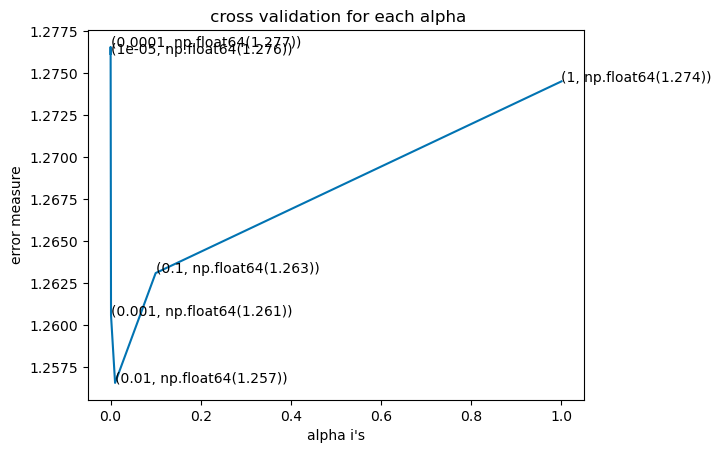

For values of best alpha =  0.01 The train log loss is: 0.848517183703391
For values of best alpha =  0.01 The cross validation log loss is: 1.2565757581597443
For values of best alpha =  0.01 The test log loss is: 1.2771604335925952


In [56]:
from sklearn.naive_bayes import MultinomialNB

alpha=[10**x for x in range(-5,1)]
cv_log_error_array=[]

for i in alpha:
    clf=MultinomialNB(alpha=i)
    sig_clf = CalibratedClassifierCV(clf,method='sigmoid',n_jobs=-1)
    sig_clf.fit(train_x_onehotcoding,train_y)
    sig_clf_probs= sig_clf.predict_proba(cv_x_onehotCoding )
    cv_log_error_array.append(log_loss(cv_y,sig_clf_probs,labels=sig_clf.classes_))
    print("for the value of alpha ",i,"the cross validation log  loss error is",log_loss(cv_y,sig_clf_probs))

fig , ax = plt.subplots()
ax.plot(alpha,cv_log_error_array)
for i,txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],np.round(txt,3)),(alpha[i],cv_log_error_array[i]))
plt.xlabel("alpha i's")
plt.ylabel("error measure")
plt.title(" cross validation for each alpha")
plt.show()



best_alpha = np.argmin(cv_log_error_array)
clf = MultinomialNB(alpha=alpha[best_alpha])
# clf.fit(train_x_onehotCoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_onehotcoding, train_y)


predict_y = sig_clf.predict_proba(train_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The train log loss is:",log_loss(y_train, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(cv_x_onehotCoding)
print('For values of best alpha = ', alpha[best_alpha], "The cross validation log loss is:",log_loss(y_cv, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(test_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The test log loss is:",log_loss(y_test, predict_y, labels=sig_clf.classes_))





the log_loss on cross validation for best alpha 0.01 is 1.2744956378368868
the fraction of missclassified points is 0.37781954887218044
==================== confusion_matrix ====================


C:\Users\nandh\AppData\Local\Temp\ipykernel_19208\173717667.py:5: RuntimeWarning: invalid value encountered in divide
  precision=cfn_matrix/cfn_matrix.sum(axis=0)


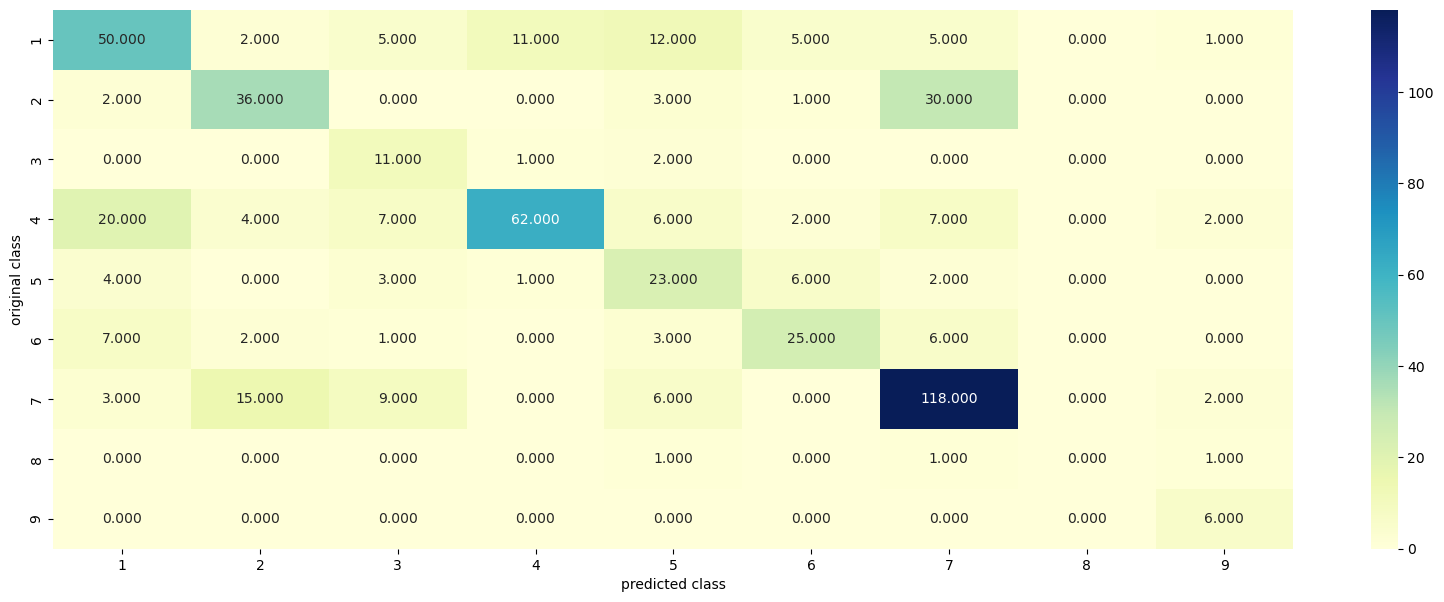

==================== recall ====================


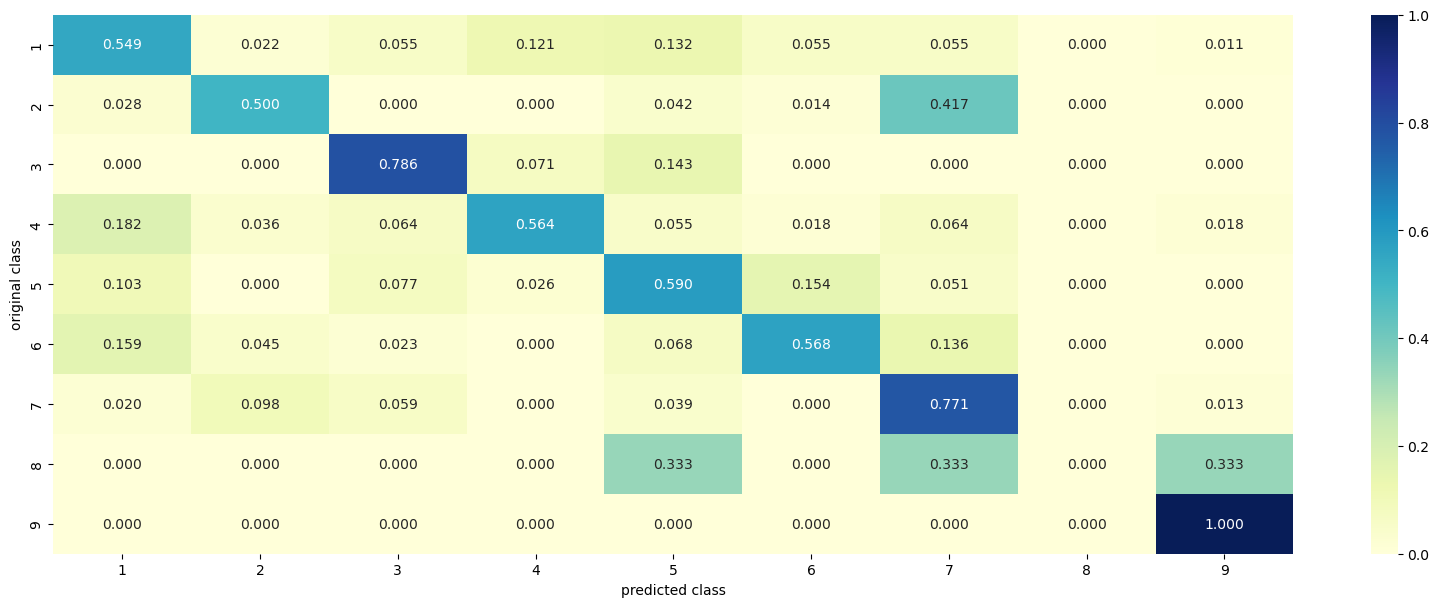

==================== precision ====================


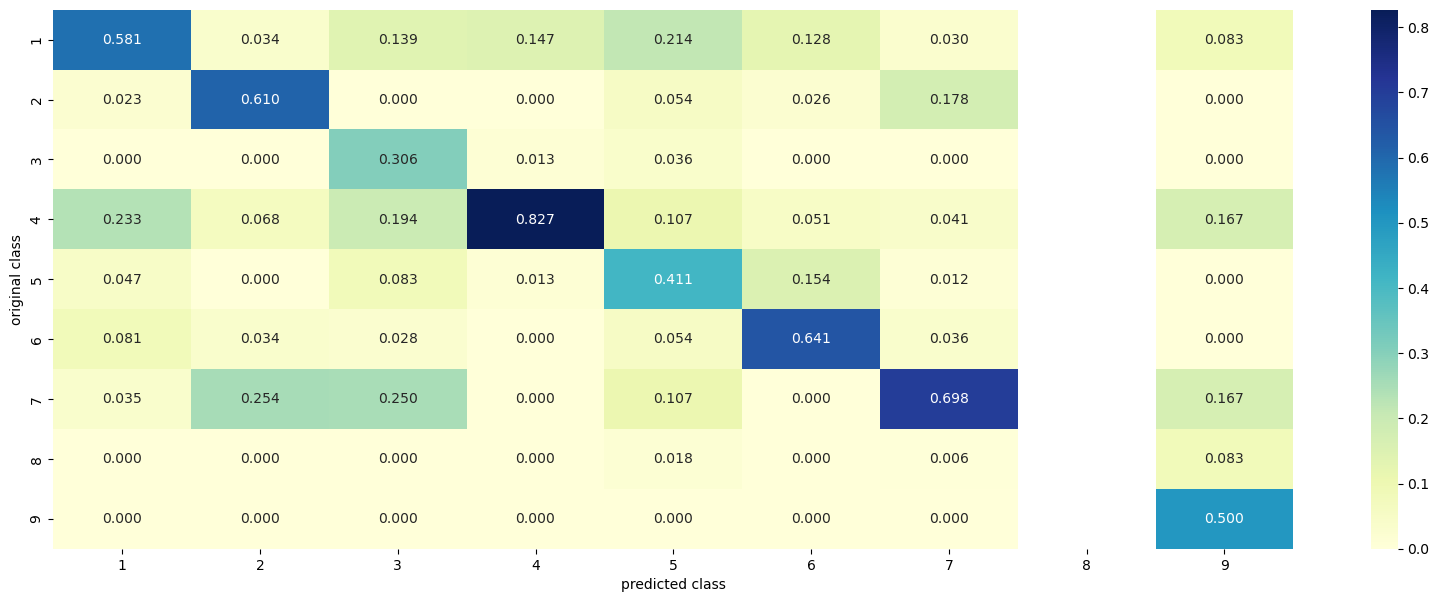

In [57]:
best_alpha = np.argmin(cv_log_error_array)
clf = MultinomialNB(alpha=alpha[best_alpha])
clf.fit(train_x_onehotcoding, train_y)
clf.fit(train_x_onehotcoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_onehotcoding, train_y)
sig_clf_predict=sig_clf.predict(cv_x_onehotCoding)

print ("the log_loss on cross validation for best alpha {} is {}".format(alpha[best_alpha],log_loss(y_cv,sig_clf_probs , labels=sig_clf.classes_)))
print("the fraction of missclassified points is", np.count_nonzero(sig_clf_predict-cv_y)/cv_y.shape[0])
plot_confusion_matrix(cv_y,sig_clf_predict)


### feature importance  of incorrectly classified points

In [58]:
test_point_index = 1
no_features =100
predicted_class = sig_clf.predict(test_x_onehotcoding[test_point_index])
print ("the predicted class of text point is",predicted_class[0] )
print("the predicted class probabilities",sig_clf.predict_proba(test_x_onehotcoding[test_point_index]))
print("the actual class of the test point",test_y[test_point_index])
print("="*60)
feature_log_prob = clf.feature_log_prob_
indices=np.argsort(-feature_log_prob[predicted_class[0]-1]).flatten()[:no_features]
get_impfeature_names(indices,test_df['Gene'].iloc[test_point_index],test_df['Variation'].iloc[test_point_index],test_df['TEXT'].iloc[test_point_index],no_features)

the predicted class of text point is 1
the predicted class probabilities [[0.38259713 0.09126916 0.01208577 0.12683156 0.2043424  0.04182704
  0.12930863 0.0060584  0.00567991]]
the actual class of the test point 5
out of top  100 features 0 are present in test in query point


### featue importance , correctly classified point

In [59]:
test_point_index = 8
no_feature = 100
predicted_cls = sig_clf.predict(test_x_onehotcoding[test_point_index])

print("Predicted Class :", predicted_cls[0])
print("Predicted Class Probabilities:", np.round(sig_clf.predict_proba(test_x_onehotcoding[test_point_index]),4))
print("Actual Class :", test_y[test_point_index])
print("-"*50)

feature_log_prob = clf.feature_log_prob_
indices = np.argsort(-feature_log_prob[predicted_cls[0]-1]).flatten()[: no_feature]
get_impfeature_names(indices, test_df['TEXT'].iloc[test_point_index],test_df['Gene'].iloc[test_point_index],
                     test_df['Variation'].iloc[test_point_index], no_feature)

Predicted Class : 2
Predicted Class Probabilities: [[0.0951 0.4527 0.0118 0.1222 0.0381 0.0405 0.2283 0.0059 0.0054]]
Actual Class : 7
--------------------------------------------------
16 text feature [identified] present in test data point [True]
18 text feature [sequencing] present in test data point [True]
19 text feature [novel] present in test data point [True]
20 text feature [harbored] present in test data point [True]
21 text feature [molecular] present in test data point [True]
29 text feature [present] present in test data point [True]
30 text feature [identification] present in test data point [True]
31 text feature [patient] present in test data point [True]
32 text feature [clinical] present in test data point [True]
33 text feature [15] present in test data point [True]
34 text feature [using] present in test data point [True]
35 text feature [another] present in test data point [True]
36 text feature [gene] present in test data point [True]
37 text feature [pcr] present

# KNN Classifier

for alpha = 5
Log Loss : 2.13878455993743
for alpha = 11
Log Loss : 1.8681985556955993
for alpha = 15
Log Loss : 1.8260804612363553
for alpha = 21
Log Loss : 1.796646628798174
for alpha = 31
Log Loss : 1.8594435937137646
for alpha = 41
Log Loss : 1.7830423960411927
for alpha = 51
Log Loss : 1.7204409150666515
for alpha = 99
Log Loss : 2.1223966363307882


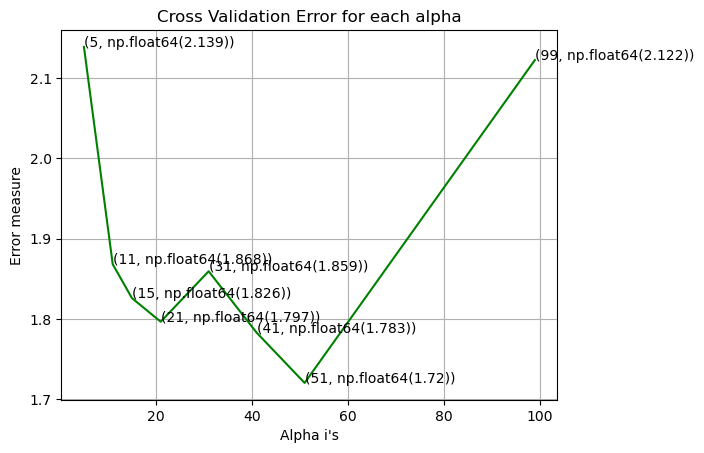

For values of best alpha =  51 The train log loss is: 0.7680205988961477
For values of best alpha =  51 The cross validation log loss is: 1.7204409150666515
For values of best alpha =  51 The test log loss is: 1.8885761390605693


In [60]:
from sklearn.neighbors import KNeighborsClassifier

alpha = [5, 11, 15, 21, 31, 41, 51, 99]
cv_log_error_array = []
for i in alpha:
    print("for alpha =", i)
    clf = KNeighborsClassifier(n_neighbors=i)
    clf.fit(train_x_responseCoding, train_y)
    sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
    sig_clf.fit(train_x_responseCoding, train_y)
    sig_clf_probs = sig_clf.predict_proba(cv_x_responseCoding)
    cv_log_error_array.append(log_loss(cv_y, sig_clf_probs, labels=sig_clf.classes_))
    
    print("Log Loss :",log_loss(cv_y, sig_clf_probs))

fig, ax = plt.subplots()
ax.plot(alpha, cv_log_error_array,c='g')
for i, txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],np.round(txt,3)), (alpha[i],cv_log_error_array[i]))
plt.grid()
plt.title("Cross Validation Error for each alpha")
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()


best_alpha = np.argmin(cv_log_error_array)
clf = KNeighborsClassifier(n_neighbors=alpha[best_alpha])
clf.fit(train_x_responseCoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_responseCoding, train_y)

predict_y = sig_clf.predict_proba(train_x_responseCoding)
print('For values of best alpha = ', alpha[best_alpha], "The train log loss is:",log_loss(y_train, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(cv_x_responseCoding)
print('For values of best alpha = ', alpha[best_alpha], "The cross validation log loss is:",log_loss(y_cv, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(test_x_responseCoding)
print('For values of best alpha = ', alpha[best_alpha], "The test log loss is:",log_loss(y_test, predict_y, labels=sig_clf.classes_))

the log loss of the model is 1.7204409150666515
the fraction of missclassified points 0.5676691729323309
==================== confusion_matrix ====================


C:\Users\nandh\AppData\Local\Temp\ipykernel_19208\173717667.py:5: RuntimeWarning: invalid value encountered in divide
  precision=cfn_matrix/cfn_matrix.sum(axis=0)


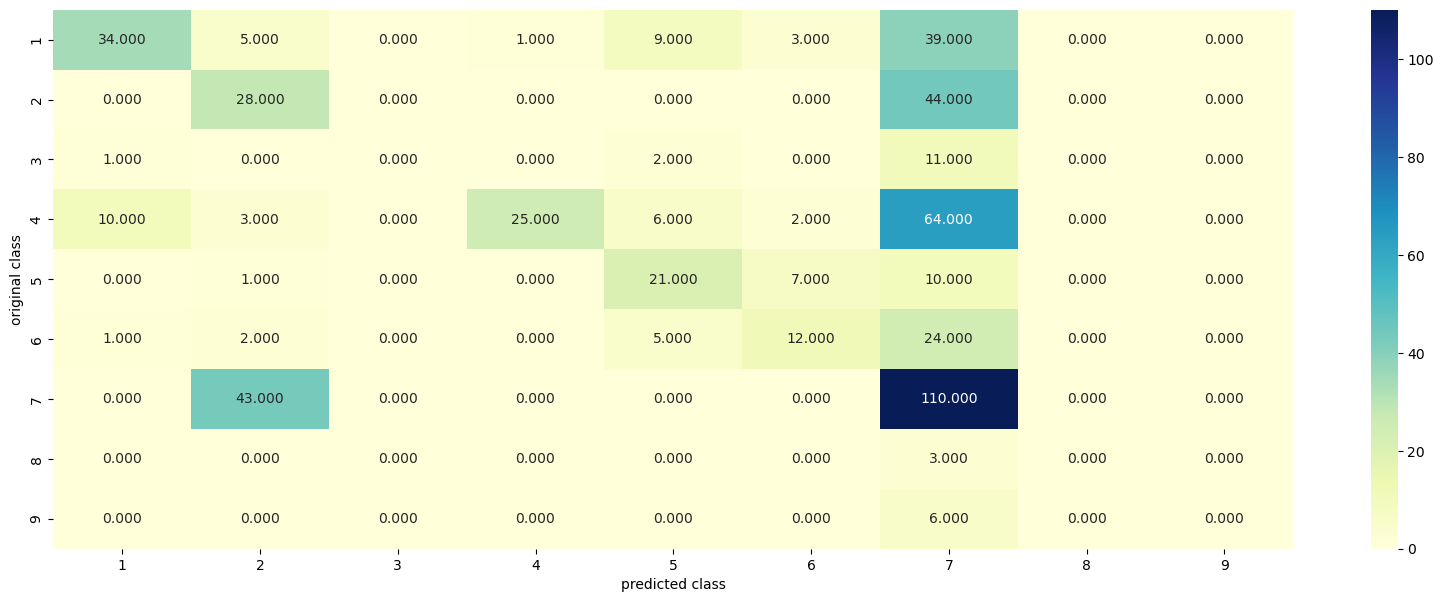

==================== recall ====================


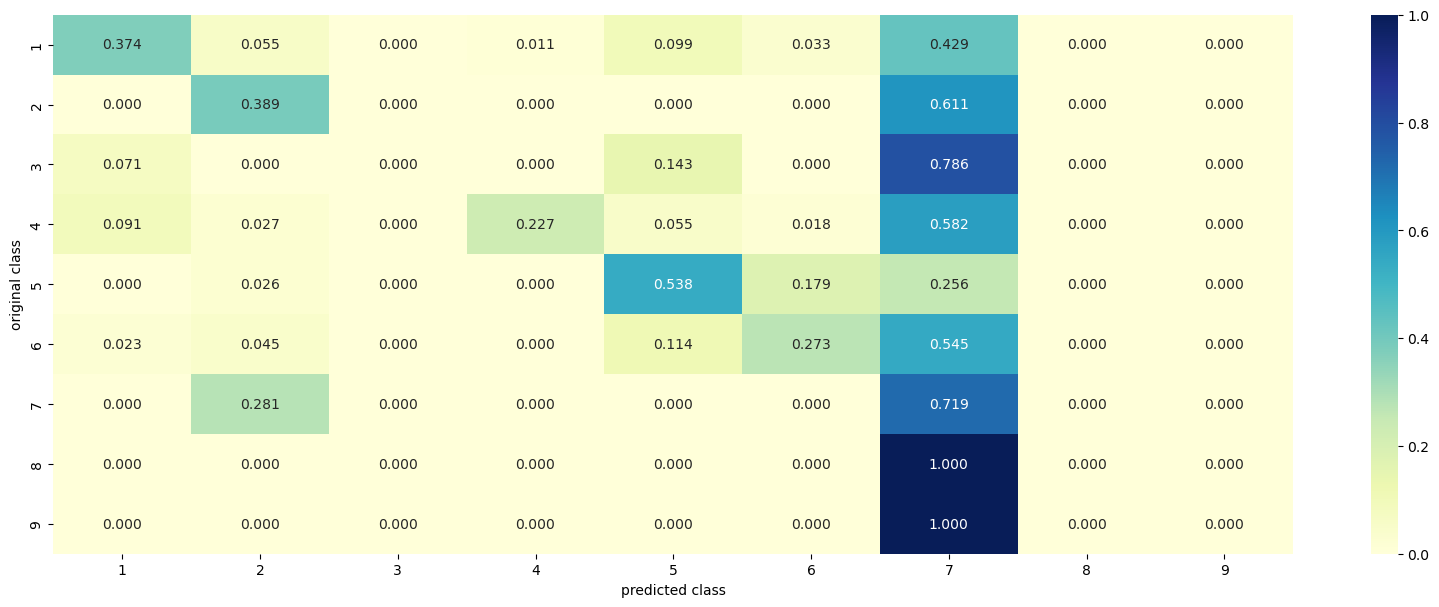

==================== precision ====================


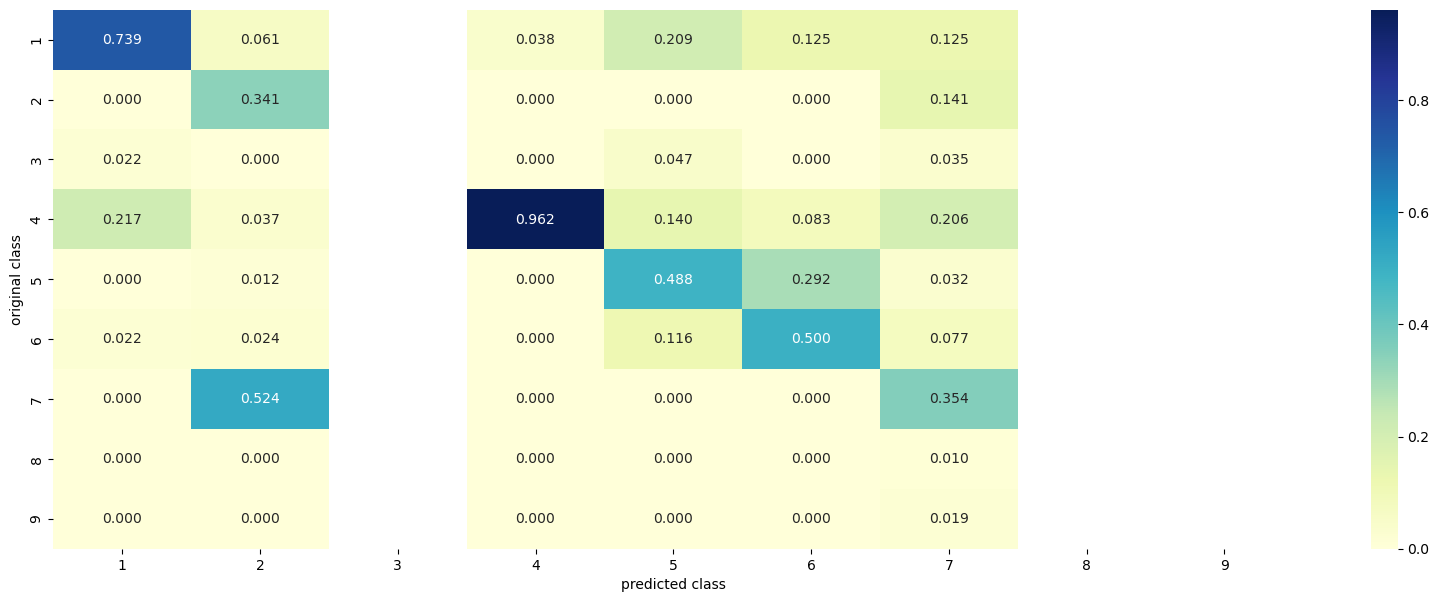

In [61]:
print ("the log loss of the model is",log_loss(cv_y,sig_clf.predict_proba(cv_x_responseCoding)))
print("the fraction of missclassified points",np.count_nonzero((cv_y-sig_clf.predict(cv_x_responseCoding)))/cv_y.shape[0])
plot_confusion_matrix(cv_y,sig_clf.predict(cv_x_responseCoding))


#### query point 1

In [62]:
clf = KNeighborsClassifier(n_neighbors=alpha[best_alpha])
clf.fit(train_x_responseCoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_responseCoding, train_y)


test_point_index = 6
predicted_class=sig_clf.predict(test_x_responseCoding[test_point_index].reshape(1,-1))

print("the predicted class of point :",predicted_class[0])
print("the actual class of the point",test_y[test_point_index])
neighbors_dist,neighbors =clf.kneighbors(test_x_responseCoding[test_point_index].reshape(1,-1),alpha[best_alpha])
print("the ",alpha[best_alpha] ,"neighbors of the text points are",train_y[neighbors[0]])
print("the frequency of classes of near points is",Counter(train_y[neighbors[0]]))

the predicted class of point : 7
the actual class of the point 7
the  51 neighbors of the text points are [7 2 6 7 7 7 2 6 2 7 7 7 2 6 7 7 2 7 7 7 2 7 7 2 2 6 6 6 6 7 7 2 2 2 2 2 7
 7 7 7 7 7 2 7 7 2 2 4 1 1 6]
the frequency of classes of near points is Counter({np.int64(7): 24, np.int64(2): 16, np.int64(6): 8, np.int64(1): 2, np.int64(4): 1})


#### query point 2

In [63]:
clf = KNeighborsClassifier(n_neighbors=alpha[best_alpha])
clf.fit(train_x_responseCoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_responseCoding, train_y)


test_point_index = 14
predicted_class=sig_clf.predict(test_x_responseCoding[test_point_index].reshape(1,-1))

print("the predicted class of point :",predicted_class[0])
print("the actual class of the point",test_y[test_point_index])
neighbors_dist,neighbors =clf.kneighbors(test_x_responseCoding[test_point_index].reshape(1,-1),alpha[best_alpha])
print("the ",alpha[best_alpha] ,"neighbors of the text points are",train_y[neighbors[0]])
print("the frequency of classes of near points is",Counter(train_y[neighbors[0]]))

the predicted class of point : 7
the actual class of the point 6
the  51 neighbors of the text points are [7 7 2 2 7 6 6 6 6 2 6 7 6 2 2 6 7 7 7 7 2 2 2 2 7 7 2 7 7 7 7 7 7 7 7 2 7
 7 2 7 7 2 7 7 2 4 4 1 1 1 1]
the frequency of classes of near points is Counter({np.int64(7): 24, np.int64(2): 14, np.int64(6): 7, np.int64(1): 4, np.int64(4): 2})


# LOGISTIC Regression

### with class balancing

for alpha = 1e-06
Log Loss : 1.3480039173822462
for alpha = 1e-05
Log Loss : 1.3110912560636834
for alpha = 0.0001
Log Loss : 1.131163211455103
for alpha = 0.001
Log Loss : 1.124548412979966
for alpha = 0.01
Log Loss : 1.2032776805786185
for alpha = 0.1
Log Loss : 1.466068639177292
for alpha = 1
Log Loss : 1.7062383524503986
for alpha = 10
Log Loss : 1.7348835309138535
for alpha = 100
Log Loss : 1.7378671798248524


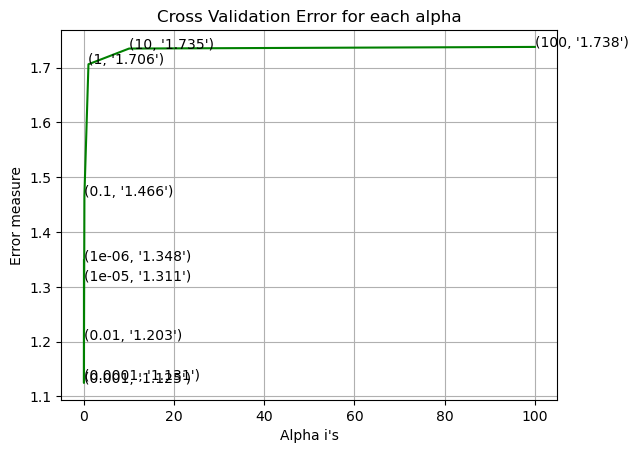

For values of best alpha =  0.001 The train log loss is: 0.512042615400552
For values of best alpha =  0.001 The cross validation log loss is: 1.124548412979966
For values of best alpha =  0.001 The test log loss is: 1.134508058722378


In [64]:


alpha = [10 ** x for x in range(-6, 3)]
cv_log_error_array = []
for i in alpha:
    print("for alpha =", i)
    clf = SGDClassifier(class_weight='balanced', alpha=i, penalty='l2', loss='log_loss', random_state=42)
    clf.fit(train_x_onehotcoding, train_y)
    sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
    sig_clf.fit(train_x_onehotcoding, train_y)
    sig_clf_probs = sig_clf.predict_proba(cv_x_onehotCoding)
    cv_log_error_array.append(log_loss(cv_y, sig_clf_probs, labels=sig_clf.classes_))
    # to avoid rounding error while multiplying probabilites we use log-probability estimates
    print("Log Loss :",log_loss(cv_y, sig_clf_probs)) 

fig, ax = plt.subplots()
ax.plot(alpha, cv_log_error_array,c='g')
for i, txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],str(txt)), (alpha[i],cv_log_error_array[i]))
plt.grid()
plt.title("Cross Validation Error for each alpha")
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()


best_alpha = np.argmin(cv_log_error_array)
clf = SGDClassifier(class_weight='balanced', alpha=alpha[best_alpha], penalty='l2', loss='log_loss', random_state=42)
clf.fit(train_x_onehotcoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_onehotcoding, train_y)

predict_y = sig_clf.predict_proba(train_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The train log loss is:",log_loss(y_train, predict_y, labels=sig_clf.classes_ ))
predict_y = sig_clf.predict_proba(cv_x_onehotCoding)
print('For values of best alpha = ', alpha[best_alpha], "The cross validation log loss is:",log_loss(y_cv, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(test_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The test log loss is:",log_loss(y_test, predict_y, labels=sig_clf.classes_))

the log loss for model is: 1.124548412979966
the fraction of missclassified points are 0.3233082706766917
==================== confusion_matrix ====================


C:\Users\nandh\AppData\Local\Temp\ipykernel_19208\173717667.py:5: RuntimeWarning: invalid value encountered in divide
  precision=cfn_matrix/cfn_matrix.sum(axis=0)


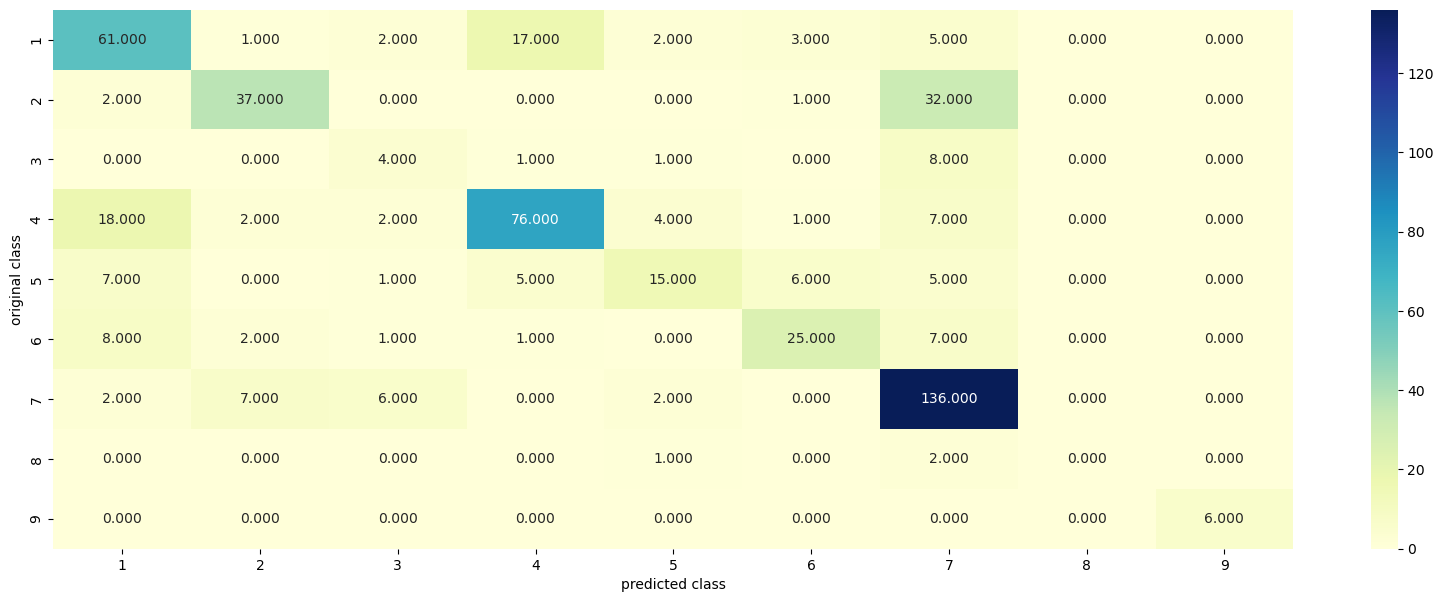

==================== recall ====================


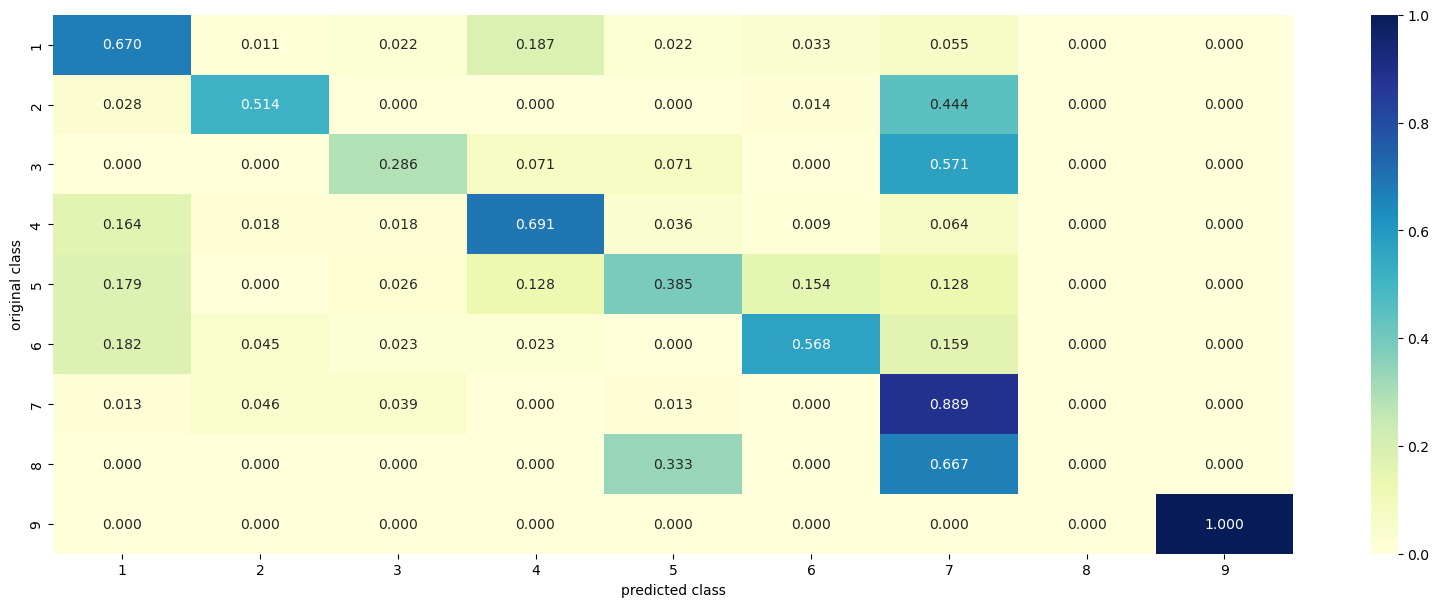

==================== precision ====================


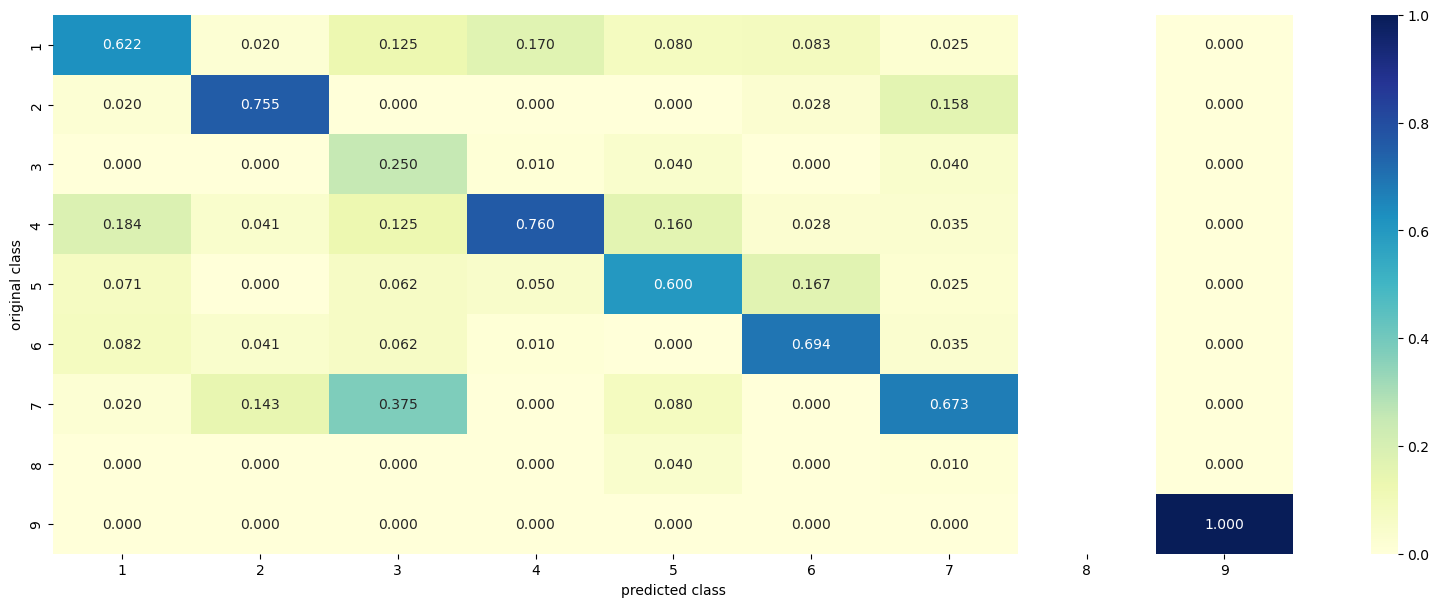

In [65]:
best_alpha = np.argmin(cv_log_error_array)
clf = SGDClassifier(class_weight='balanced', alpha=alpha[best_alpha], penalty='l2', loss='log_loss', random_state=42)
clf.fit(train_x_onehotcoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_onehotcoding, train_y)



print("the log loss for model is:",log_loss(cv_y,sig_clf.predict_proba(cv_x_onehotCoding),labels=sig_clf.classes_))
print("the fraction of missclassified points are",np.count_nonzero(cv_y-sig_clf.predict(cv_x_onehotCoding))/cv_y.shape[0])
plot_confusion_matrix(cv_y,sig_clf.predict(cv_x_onehotCoding))

In [66]:
clf = SGDClassifier(class_weight='balanced', alpha=alpha[best_alpha], penalty='l2', loss='log_loss', random_state=42)
clf.fit(train_x_onehotcoding,train_y)
test_point_index = 1
no_feature = 500
predicted_cls = sig_clf.predict(test_x_onehotcoding[test_point_index])
print("Predicted Class :", predicted_cls[0])
print("Predicted Class Probabilities:", np.round(sig_clf.predict_proba(test_x_onehotcoding[test_point_index]),4))
print("Actual Class :", test_y[test_point_index])
indices = np.argsort(-clf.coef_)[predicted_cls-1][:,:no_feature]
print("-"*50)
get_impfeature_names(indices[0], test_df['TEXT'].iloc[test_point_index],test_df['Gene'].iloc[test_point_index],
                     test_df['Variation'].iloc[test_point_index], no_feature)

Predicted Class : 1
Predicted Class Probabilities: [[8.733e-01 2.800e-03 3.000e-04 7.450e-02 3.730e-02 6.700e-03 9.000e-04
  3.500e-03 8.000e-04]]
Actual Class : 5
--------------------------------------------------
95 text feature [tnt] present in test data point [True]
100 text feature [u43746] present in test data point [True]
176 text feature [doctors] present in test data point [True]
178 text feature [ashkenazim] present in test data point [True]
253 text feature [ter] present in test data point [True]
269 text feature [athens] present in test data point [True]
303 text feature [stop] present in test data point [True]
332 text feature [premature] present in test data point [True]
337 text feature [frameshift] present in test data point [True]
354 text feature [greece] present in test data point [True]
360 text feature [ptt] present in test data point [True]
362 text feature [exon20] present in test data point [True]
370 text feature [absolutely] present in test data point [True]
3

In [67]:

test_point_index = 113
no_feature = 500
predicted_cls = sig_clf.predict(test_x_onehotcoding[test_point_index])
print("Predicted Class :", predicted_cls[0])
print("Predicted Class Probabilities:", np.round(sig_clf.predict_proba(test_x_onehotcoding[test_point_index]),4))
print("Actual Class :", test_y[test_point_index])
indices = np.argsort(-clf.coef_)[predicted_cls-1][:,:no_feature]
print("-"*50)
get_impfeature_names(indices[0], test_df['TEXT'].iloc[test_point_index],test_df['Gene'].iloc[test_point_index],
                     test_df['Variation'].iloc[test_point_index], no_feature)

Predicted Class : 1
Predicted Class Probabilities: [[0.548  0.1013 0.0248 0.0682 0.0556 0.0666 0.118  0.0052 0.0123]]
Actual Class : 1
--------------------------------------------------
307 text feature [runx1t1] present in test data point [True]
337 text feature [frameshift] present in test data point [True]
401 text feature [truncating] present in test data point [True]
460 text feature [q22] present in test data point [True]
out of top  500 features 4 are present in test in query point


### without class balancing

for alpha = 1e-06
Log Loss : 1.325185650028154
for alpha = 1e-05
Log Loss : 1.2834568000063813
for alpha = 0.0001
Log Loss : 1.150468598249311
for alpha = 0.001
Log Loss : 1.1436785685765374
for alpha = 0.01
Log Loss : 1.2546983698636183
for alpha = 0.1
Log Loss : 1.4434658025934606
for alpha = 1
Log Loss : 1.6271166290622487


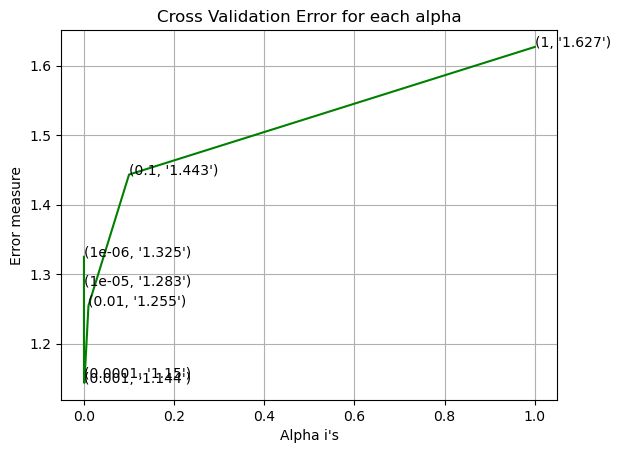

For values of best alpha =  0.001 The train log loss is: 0.51170713638907
For values of best alpha =  0.001 The cross validation log loss is: 1.1436785685765374
For values of best alpha =  0.001 The test log loss is: 1.141727373467306


In [68]:
alpha = [10 ** x for x in range(-6, 1)]
cv_log_error_array = []
for i in alpha:
    print("for alpha =", i)
    clf = SGDClassifier(alpha=i, penalty='l2', loss='log_loss', random_state=42)
    clf.fit(train_x_onehotcoding, train_y)
    sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
    sig_clf.fit(train_x_onehotcoding, train_y)
    sig_clf_probs = sig_clf.predict_proba(cv_x_onehotCoding)
    cv_log_error_array.append(log_loss(cv_y, sig_clf_probs, labels=sig_clf.classes_))
    print("Log Loss :",log_loss(cv_y, sig_clf_probs)) 

fig, ax = plt.subplots()
ax.plot(alpha, cv_log_error_array,c='g')
for i, txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],str(txt)), (alpha[i],cv_log_error_array[i]))
plt.grid()
plt.title("Cross Validation Error for each alpha")
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()

best_alpha = np.argmin(cv_log_error_array)
clf = SGDClassifier(alpha=alpha[best_alpha], penalty='l2', loss='log_loss', random_state=42)
clf.fit(train_x_onehotcoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_onehotcoding, train_y)

predict_y = sig_clf.predict_proba(train_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The train log loss is:",log_loss(y_train, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(cv_x_onehotCoding)
print('For values of best alpha = ', alpha[best_alpha], "The cross validation log loss is:",log_loss(y_cv, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(test_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The test log loss is:",log_loss(y_test, predict_y, labels=sig_clf.classes_))



 the log_loss of the model  1.1436785685765374
the fraction of missclassified  points 0.3233082706766917
==================== confusion_matrix ====================


C:\Users\nandh\AppData\Local\Temp\ipykernel_19208\173717667.py:5: RuntimeWarning: invalid value encountered in divide
  precision=cfn_matrix/cfn_matrix.sum(axis=0)


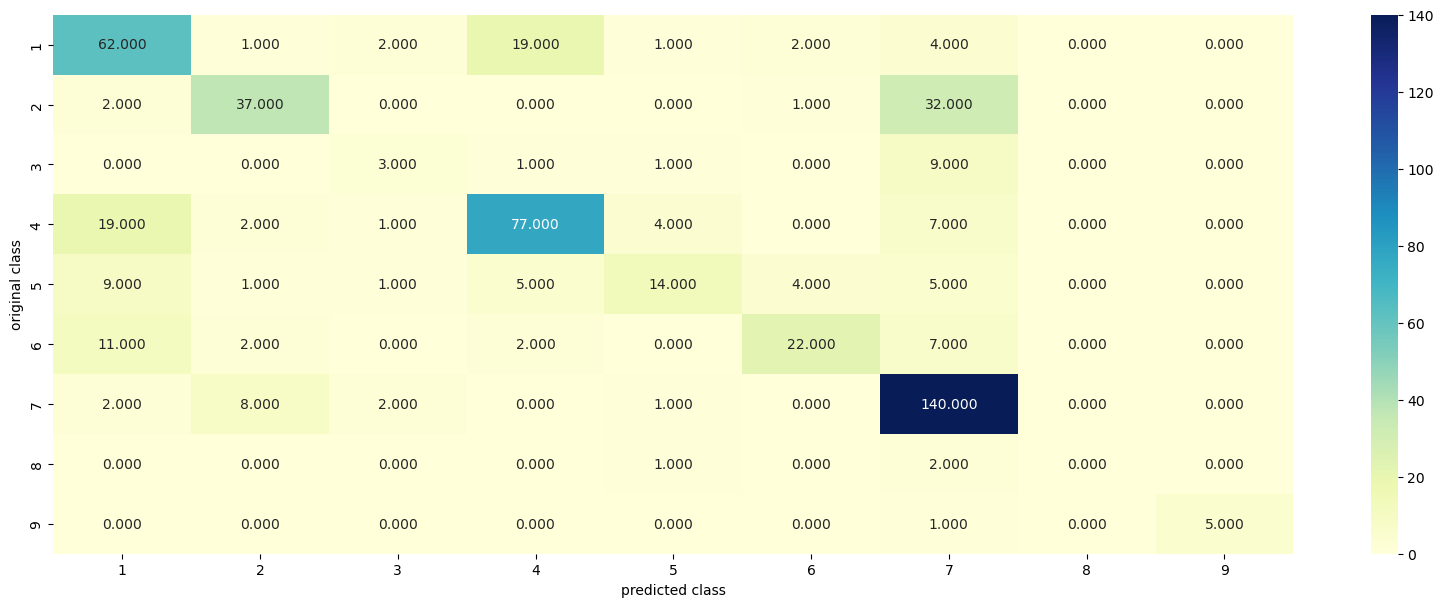

==================== recall ====================


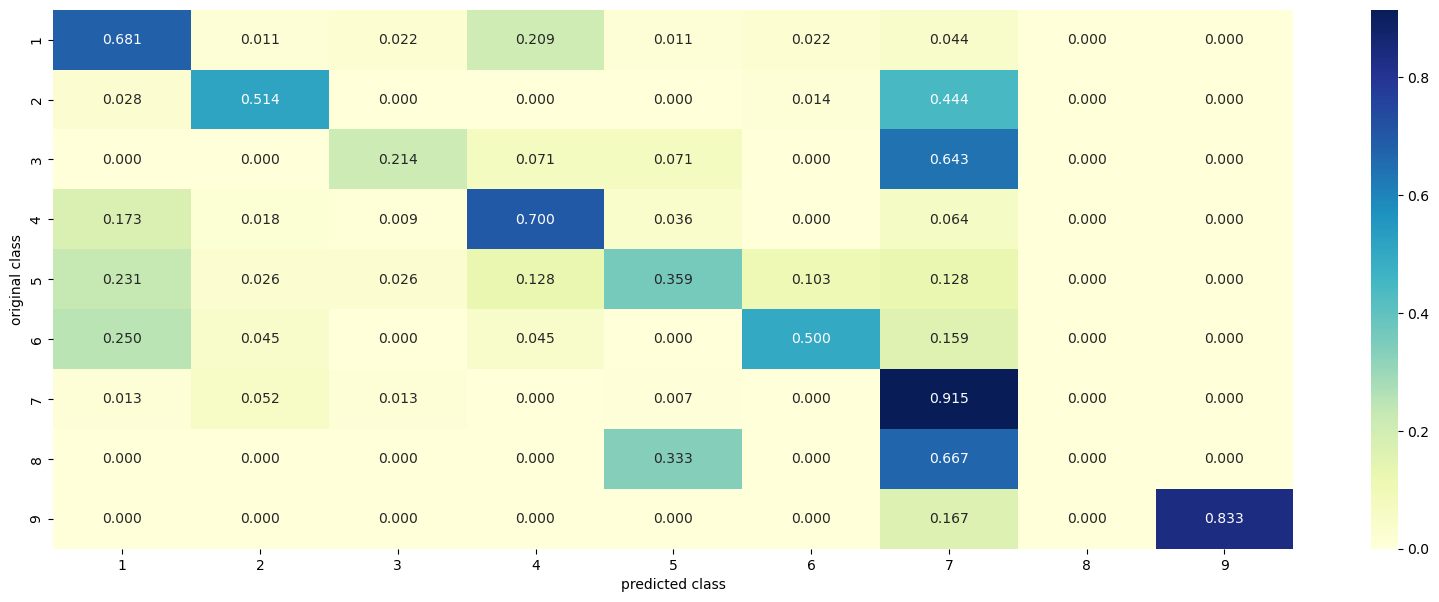

==================== precision ====================


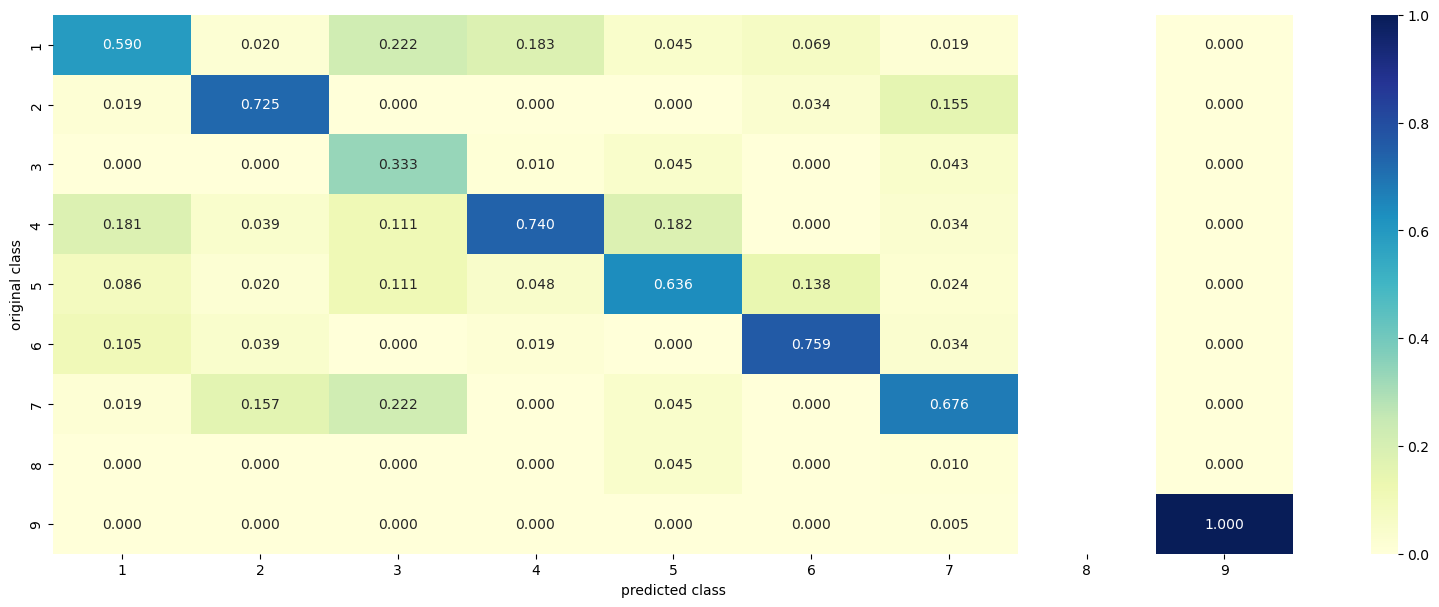

In [69]:
print(" the log_loss of the model ",log_loss(cv_y,sig_clf.predict_proba(cv_x_onehotCoding)))
print("the fraction of missclassified  points",np.count_nonzero(cv_y-sig_clf.predict(cv_x_onehotCoding))/cv_y.shape[0])
plot_confusion_matrix(cv_y,sig_clf.predict(cv_x_onehotCoding))

In [70]:
text_point_index =119
no_features=500
predicted_cls=sig_clf.predict(test_x_onehotcoding[text_point_index])
predicted_class_proba=sig_clf.predict_proba(test_x_onehotcoding[text_point_index])
print("the predicted class is",predicted_cls[0])
print("the predicted probability classes",predicted_class_proba)
print("the actuall class is",test_y[text_point_index ])


the predicted class is 1
the predicted probability classes [[4.45887306e-01 2.53671118e-03 1.67274492e-04 2.56092400e-01
  4.51260890e-02 2.43246558e-01 1.47522438e-03 3.85925093e-03
  1.60918554e-03]]
the actuall class is 4


In [71]:
text_point_index =10
no_features=500
predicted_cls=sig_clf.predict(test_x_onehotcoding[text_point_index])
predicted_class_proba=sig_clf.predict_proba(test_x_onehotcoding[text_point_index])
print("the predicted class is",predicted_cls[0])
print("the predicted probability classes",predicted_class_proba)
print("the actuall class is",test_y[text_point_index ])
indices= np.argsort(-clf.coef_[predicted_cls[0]-1])[:no_features]
get_impfeature_names(indices,test_df['Gene'].iloc[text_point_index],test_df['Variation'].iloc[text_point_index],
                     test_df['TEXT'].iloc[text_point_index],no_features)

the predicted class is 1
the predicted probability classes [[8.10631376e-01 1.79011695e-01 5.09541961e-05 2.66168860e-03
  8.26780053e-04 2.52969447e-04 3.16316473e-03 2.77768009e-03
  6.23691816e-04]]
the actuall class is 1
out of top  500 features 0 are present in test in query point


# Support Vector Machine

for C = 1e-05
Log Loss : 1.3063726201262171
for C = 0.0001
Log Loss : 1.2190141952821492
for C = 0.001
Log Loss : 1.1524192655023748
for C = 0.01
Log Loss : 1.1503062632483534
for C = 0.1
Log Loss : 1.3604987879529546
for C = 1
Log Loss : 1.7259650040051018
for C = 10
Log Loss : 1.738382941774131
for C = 100
Log Loss : 1.73838293324411


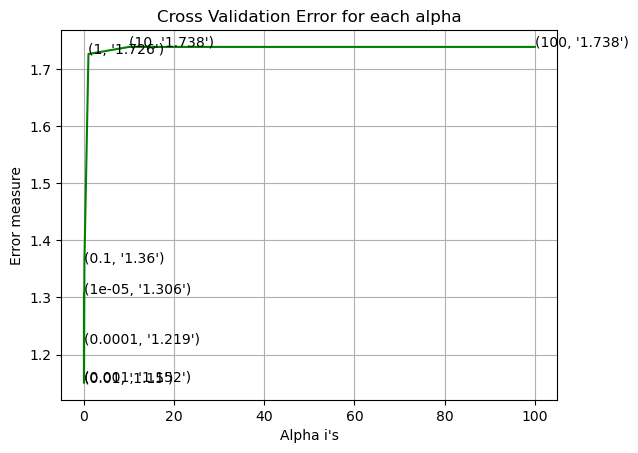

For values of best alpha =  0.01 The train log loss is: 0.7224199478053132
For values of best alpha =  0.01 The cross validation log loss is: 1.1503062632483534
For values of best alpha =  0.01 The test log loss is: 1.1798731677255343


In [72]:
alpha = [10 ** x for x in range(-5, 3)]
cv_log_error_array = []
for i in alpha:
    print("for C =", i)
#     
    clf = SGDClassifier( class_weight='balanced', alpha=i, penalty='l2', loss='hinge', random_state=42)
    clf.fit(train_x_onehotcoding, train_y)
    sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
    sig_clf.fit(train_x_onehotcoding, train_y)
    sig_clf_probs = sig_clf.predict_proba(cv_x_onehotCoding)
    cv_log_error_array.append(log_loss(cv_y, sig_clf_probs, labels=sig_clf.classes_))
    print("Log Loss :",log_loss(cv_y, sig_clf_probs)) 

fig, ax = plt.subplots()
ax.plot(alpha, cv_log_error_array,c='g')
for i, txt in enumerate(np.round(cv_log_error_array,3)):
    ax.annotate((alpha[i],str(txt)), (alpha[i],cv_log_error_array[i]))
plt.grid()
plt.title("Cross Validation Error for each alpha")
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()


best_alpha = np.argmin(cv_log_error_array)
# clf = SVC(C=i,kernel='linear',probability=True, class_weight='balanced')
clf = SGDClassifier(class_weight='balanced', alpha=alpha[best_alpha], penalty='l2', loss='hinge', random_state=42)
clf.fit(train_x_onehotcoding, train_y)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid", n_jobs=-1)
sig_clf.fit(train_x_onehotcoding, train_y)

predict_y = sig_clf.predict_proba(train_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The train log loss is:",log_loss(y_train, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(cv_x_onehotCoding)
print('For values of best alpha = ', alpha[best_alpha], "The cross validation log loss is:",log_loss(y_cv, predict_y, labels=sig_clf.classes_))
predict_y = sig_clf.predict_proba(test_x_onehotcoding)
print('For values of best alpha = ', alpha[best_alpha], "The test log loss is:",log_loss(y_test, predict_y, labels=sig_clf.classes_))


 the log_loss of the model  1.1503062632483534
the fraction of missclassified  points 0.34210526315789475
==================== confusion_matrix ====================


C:\Users\nandh\AppData\Local\Temp\ipykernel_19208\173717667.py:5: RuntimeWarning: invalid value encountered in divide
  precision=cfn_matrix/cfn_matrix.sum(axis=0)


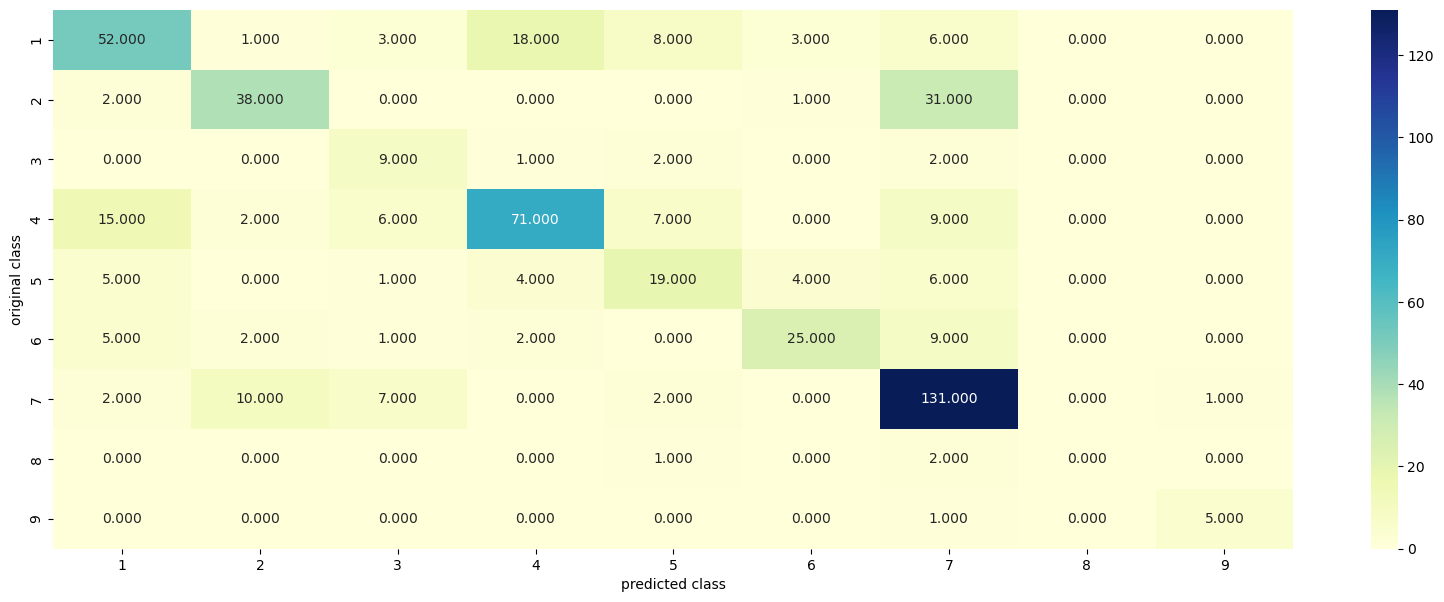

==================== recall ====================


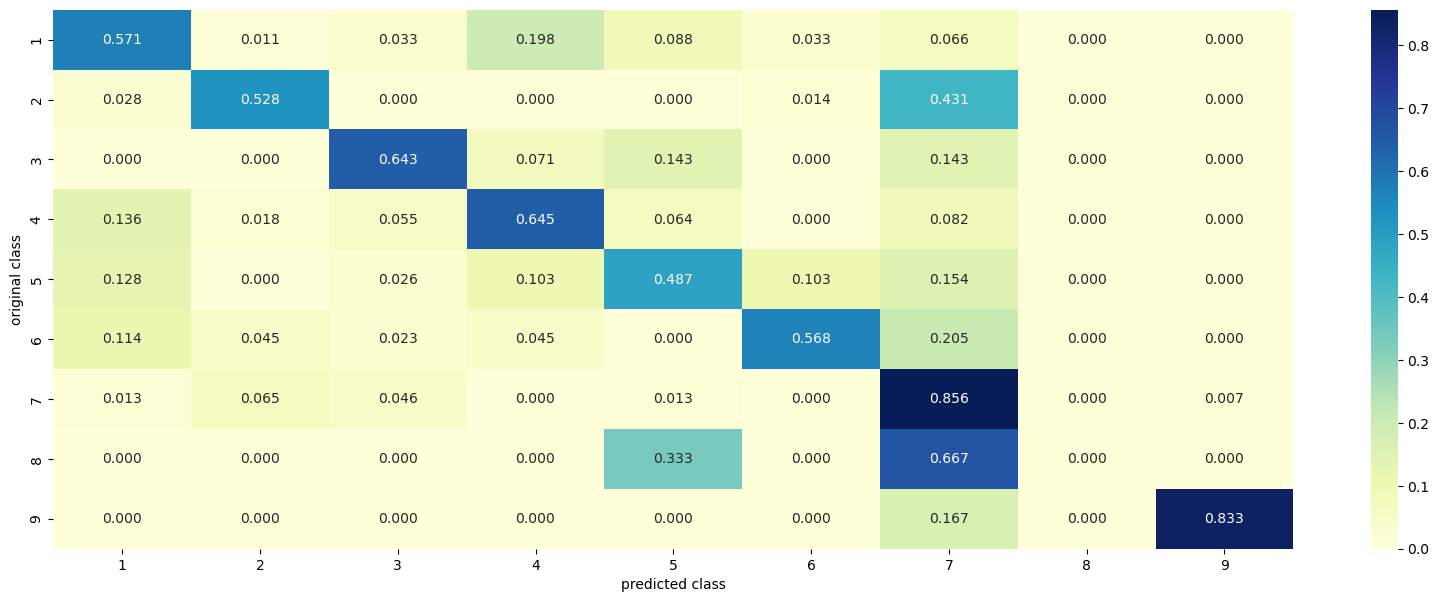

==================== precision ====================


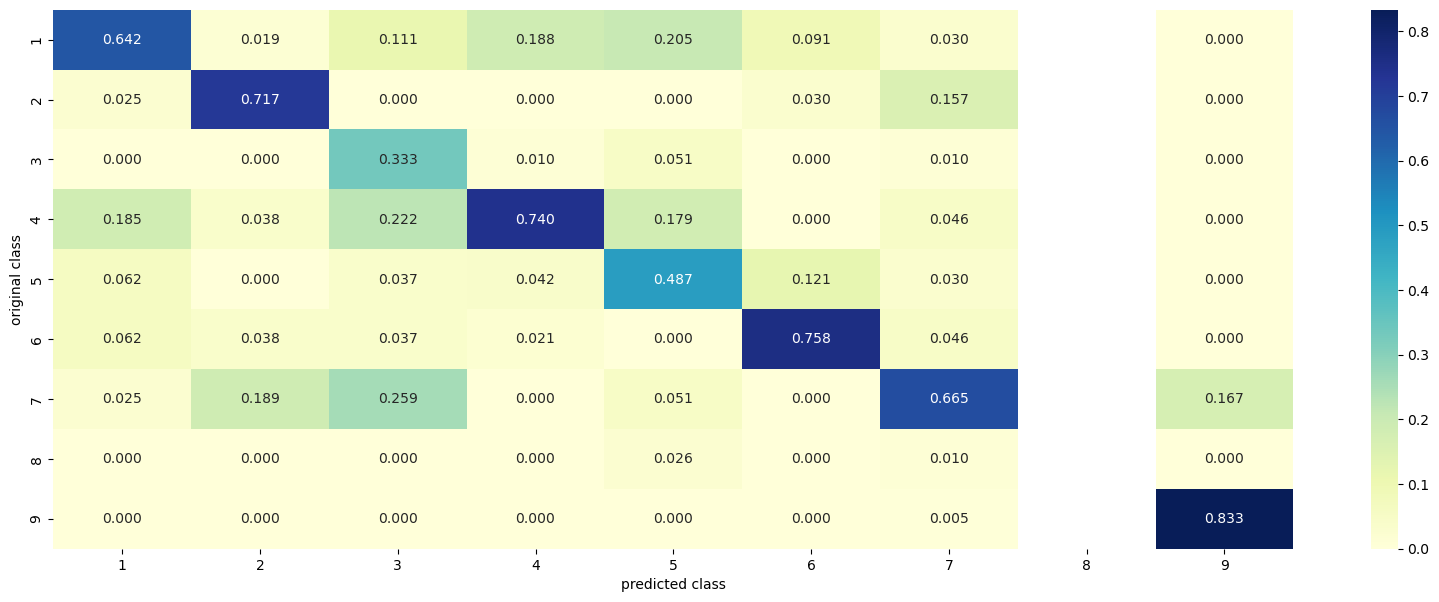

In [73]:
print(" the log_loss of the model ",log_loss(cv_y,sig_clf.predict_proba(cv_x_onehotCoding)))
print("the fraction of missclassified  points",np.count_nonzero(cv_y-sig_clf.predict(cv_x_onehotCoding))/cv_y.shape[0])
plot_confusion_matrix(cv_y,sig_clf.predict(cv_x_onehotCoding))

In [74]:
text_point_index =119
no_features=500
predicted_cls=sig_clf.predict(test_x_onehotcoding[text_point_index])
predicted_class_proba=sig_clf.predict_proba(test_x_onehotcoding[text_point_index])
print("the predicted class is",predicted_cls[0])
print("the predicted probability classes",predicted_class_proba)
print("the actuall class is",test_y[text_point_index ])


the predicted class is 6
the predicted probability classes [[0.13081899 0.03020195 0.0076023  0.05049506 0.08190479 0.63399195
  0.05237887 0.00992463 0.00268145]]
the actuall class is 4


In [75]:
text_point_index =8
no_features=500
predicted_cls=sig_clf.predict(test_x_onehotcoding[text_point_index])
predicted_class_proba=sig_clf.predict_proba(test_x_onehotcoding[text_point_index])
print("the predicted class is",predicted_cls[0])
print("the predicted probability classes",predicted_class_proba)
print("the actuall class is",test_y[text_point_index ])


the predicted class is 2
the predicted probability classes [[0.07040889 0.62245233 0.00690052 0.06133867 0.0307908  0.01436083
  0.18582083 0.00558645 0.00234066]]
the actuall class is 7


# Random Forest Classifier

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss

alpha = [100,200]
max_depth = [20,30]

cv_log_error_array = []

for i in alpha:
    for j in max_depth:
        clf = RandomForestClassifier(
            n_estimators=i,
            max_depth=j,
            random_state=42,
            n_jobs=-1
        )

        clf.fit(train_x_onehotcoding, y_train)

        sig_clf = CalibratedClassifierCV(clf, method="sigmoid")
        sig_clf.fit(train_x_onehotcoding, y_train)

        predict_y = sig_clf.predict_proba(cv_x_onehotCoding)

        cv_log_error_array.append(log_loss(y_cv, predict_y))

        print("Estimators =", i,
              "Depth =", j,
              "Log Loss :", log_loss(y_cv, predict_y))

Estimators = 100 Depth = 20 Log Loss : 1.1651480563305479
Estimators = 100 Depth = 30 Log Loss : 1.1904200771356073
Estimators = 200 Depth = 20 Log Loss : 1.1639409250063895
Estimators = 200 Depth = 30 Log Loss : 1.1832550508232844


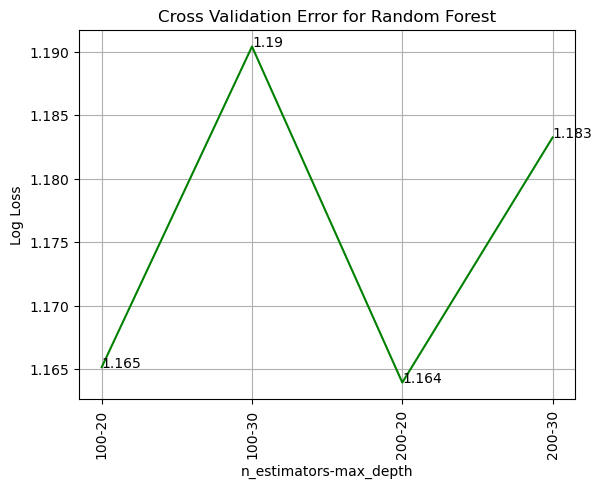

In [77]:
import matplotlib.pyplot as plt

x_axis = []
for i in alpha:
    for j in max_depth:
        x_axis.append(str(i)+"-"+str(j))

plt.plot(x_axis, cv_log_error_array, c='g')
for i in range(len(cv_log_error_array)):
    plt.annotate(round(cv_log_error_array[i],3),
                 (x_axis[i],cv_log_error_array[i]))

plt.grid()
plt.title("Cross Validation Error for Random Forest")
plt.xlabel("n_estimators-max_depth")
plt.ylabel("Log Loss")
plt.xticks(rotation=90)
plt.show()

For values of best parameter, The log loss is: 1.185203920165041
the fraction of missclassified  points 0.3684210526315789


C:\Users\nandh\AppData\Local\Temp\ipykernel_19208\173717667.py:5: RuntimeWarning: invalid value encountered in divide
  precision=cfn_matrix/cfn_matrix.sum(axis=0)


==================== confusion_matrix ====================


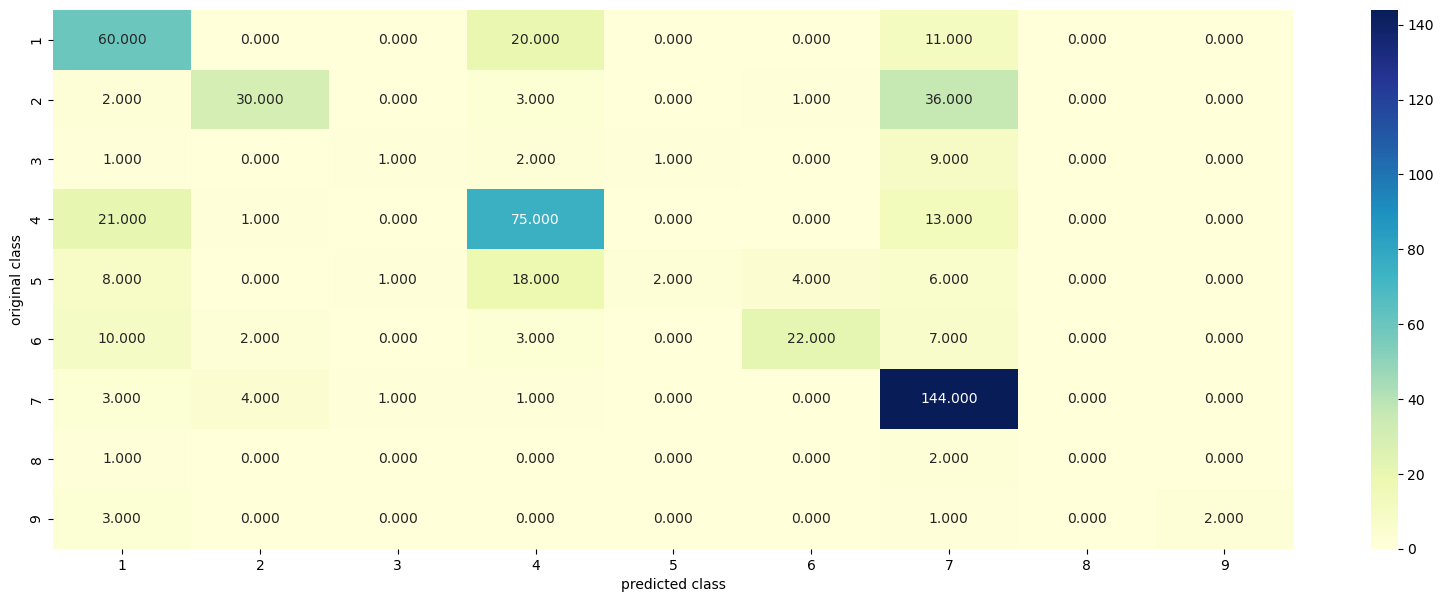

==================== recall ====================


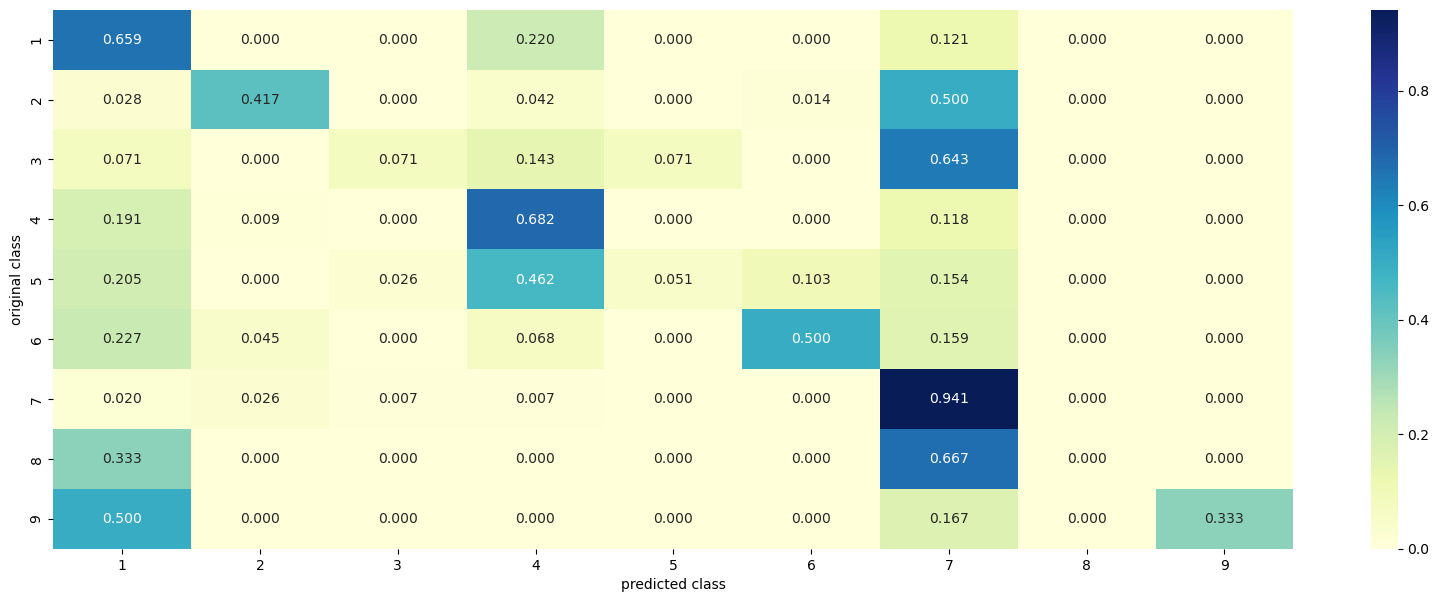

==================== precision ====================


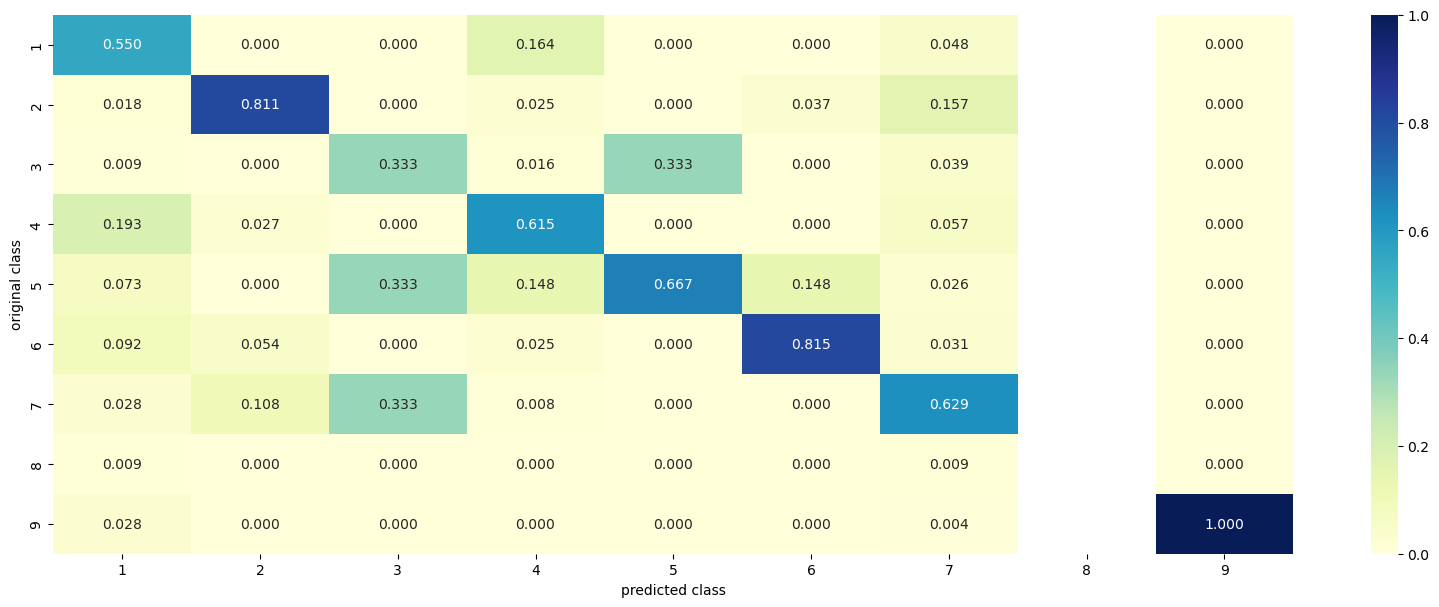

In [81]:
predict_y = sig_clf.predict_proba(test_x_onehotcoding)

print("For values of best parameter, The log loss is:",
      log_loss(y_test, predict_y))
print("the fraction of missclassified  points",np.count_nonzero(cv_y-sig_clf.predict(cv_x_onehotCoding))/cv_y.shape[0])
plot_confusion_matrix(cv_y,sig_clf.predict(cv_x_onehotCoding))

C:\Users\nandh\AppData\Local\Temp\ipykernel_19208\1414285906.py:6: RuntimeWarning: invalid value encountered in divide
  B =(C/C.sum(axis=0))


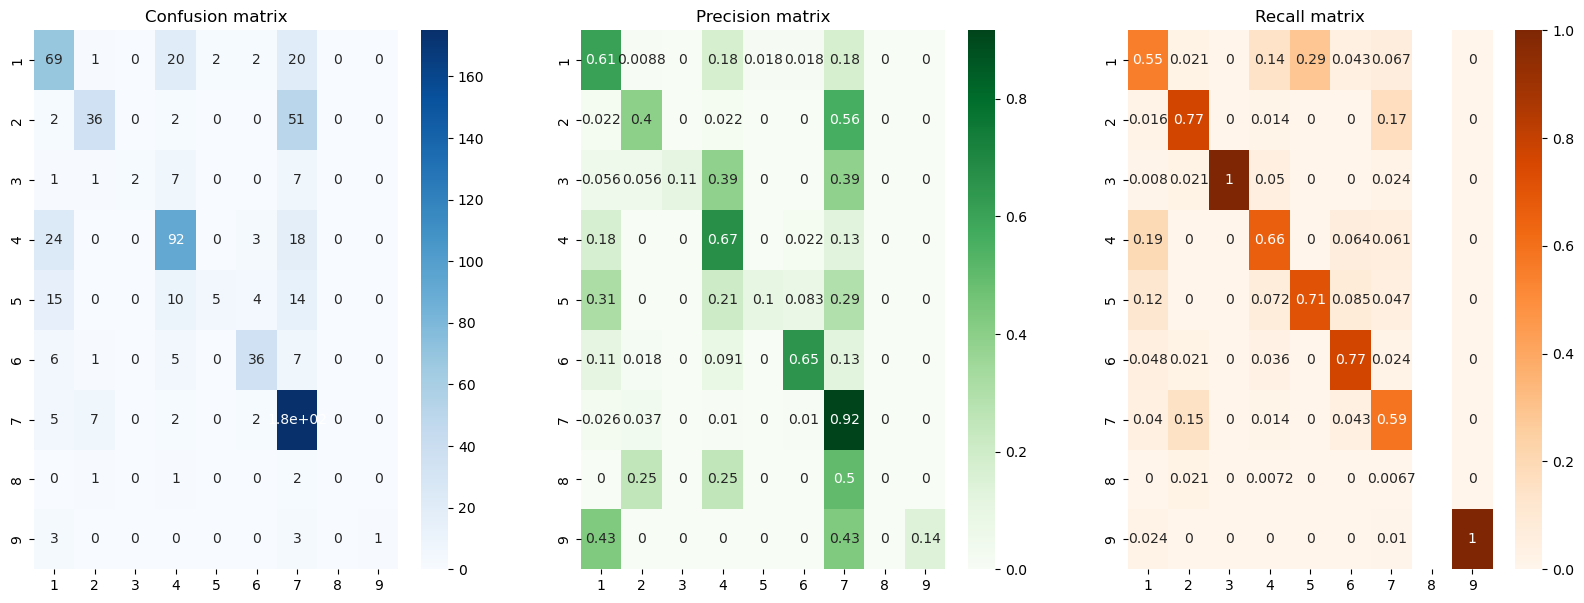

In [79]:
predict_y = sig_clf.predict(test_x_onehotcoding)

C = confusion_matrix(y_test, predict_y)

A =(((C.T)/(C.sum(axis=1))).T)
B =(C/C.sum(axis=0))

labels = [1,2,3,4,5,6,7,8,9]

plt.figure(figsize=(20,7))

plt.subplot(1,3,1)
sns.heatmap(C, annot=True, cmap="Blues",
xticklabels=labels, yticklabels=labels)
plt.title("Confusion matrix")

plt.subplot(1,3,2)
sns.heatmap(A, annot=True, cmap="Greens",
xticklabels=labels, yticklabels=labels)
plt.title("Precision matrix")

plt.subplot(1,3,3)
sns.heatmap(B, annot=True, cmap="Oranges",
xticklabels=labels, yticklabels=labels)
plt.title("Recall matrix")

plt.show()

## Naive Bayes
#### the log_loss on cross validation for best alpha 0.01 is 1.2744956378368868
#### the fraction of missclassified points is 0.37781954887218044

## KNN Classifier
#### the log loss of the model is 1.7204409150666515
####  the fraction of missclassified points 0.5676691729323309

## logistic Regression with class balancing
#### the log loss for model is: 1.124548412979966
#### the fraction of missclassified points are 0.3233082706766917

## Logistic Regression without class balancing
#### the log_loss of the model  1.1436785685765374
#### the fraction of missclassified  points 0.3233082706766917

## Support Vector Machine
####  the log_loss of the model  1.1503062632483534
####  the fraction of missclassified  points 0.34210526315789475

## Random Forest Classifier
#### The log loss of the model 1.185203920165041
#### the fraction of missclassified  points 0.3684210526315789

In [82]:
import pandas as pd

# Final results
results = {
    "Model": [
        "Naive Bayes",
        "KNN Classifier",
        "Logistic Regression (Balanced)",
        "Logistic Regression (Unbalanced)",
        "Support Vector Machine",
        "Random Forest Classifier"
    ],

    "Log Loss": [
        1.2745,
        1.7204,
        1.1245,
        1.1437,
        1.1503,
        1.1852
    ],

    "Misclassified Fraction": [
        0.3778,
        0.5677,
        0.3233,
        0.3233,
        0.3421,
        0.3684
    ]
}

# Create dataframe
df = pd.DataFrame(results)

# Accuracy %
df["Accuracy (%)"] = (1 - df["Misclassified Fraction"]) * 100

# Final columns
df = df[["Model", "Log Loss", "Accuracy (%)"]]

# Round values
df = df.round(2)

# Display
df

,Model,Log Loss,Accuracy (%)
0,Naive Bayes,1.27,62.22
1,KNN Classifier,1.72,43.23
2,Logistic Regression (Balanced),1.12,67.67
3,Logistic Regression (Unbalanced),1.14,67.67
4,Support Vector Machine,1.15,65.79
5,Random Forest Classifier,1.19,63.16
